# Example: Life After Yahoo — Three Free Routes to ESG Data

Our old `yfinance` sustainability example (file `Lecture03b - Example - YahooFinance III - Sustainability Data.ipynb`) no longer works: Yahoo has switched off the underlying ESG feed, so `Ticker.sustainability` now comes back empty for essentially every ticker. Rather than mourn it, this notebook rebuilds the lesson on **three free, sustainable sources** — each teaching a slightly different skill.

<table style="border-collapse:collapse;font-size:15px;">
<tr><td style="padding:6px 14px 6px 0;"><b>Act A</b></td>
    <td style="padding:6px 0;">A <b>static S&amp;P 500 ESG dataset</b> — the closest drop-in for the old workflow. Load, clean, style, and visualise.</td></tr>
<tr><td style="padding:6px 14px 6px 0;"><b>Act B</b></td>
    <td style="padding:6px 0;"><b>World Bank ESG data</b> — genuinely free, no API key, country-level. Where the <b>maps</b> come alive.</td></tr>
<tr><td style="padding:6px 14px 6px 0;"><b>Act C</b></td>
    <td style="padding:6px 0;"><b>SEC EDGAR</b> — primary filings straight from the source. Teaches where the numbers actually come from.</td></tr>
</table>

Throughout we work with the three ESG pillars: <span style="color:#2E8B57;"><b>Environmental (E)</b></span>, <span style="color:#1F6FEB;"><b>Social (S)</b></span> and <span style="color:#B8860B;"><b>Governance (G)</b></span>.

---

### <span style="color:#8070FE;">How to use this notebook</span>

- **Run the setup cell first**, then work top to bottom.
- **Act A works offline immediately** — the dataset ships in the `data/` folder beside this notebook.
- **Acts B and C fetch from live APIs.** Every fetch uses a *load-from-cache-or-download* helper, so the **first** "Run All" on an open connection saves the results into `data/`; after that the whole notebook runs offline and identically (ideal for a live class).
- <span style="color:#AC0000;">**For Act C:** the SEC asks you to identify yourself with a contact email in the request header. Edit the `SEC_HEADERS` line before running it. USE YOU OWN E_MAIL ADDRESS!</span>

In [90]:
# --- Setup: run me first -----------------------------------------------------
# Everything here is installable via pip. Uncomment the install line on first use.
# %pip install -q wbgapi plotly pandas requests ipywidgets

from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
px.defaults.template = "plotly_white"   # clean, projector-friendly charts

# A tiny data folder that lives next to this notebook.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def load_or_fetch_csv(filename, fetch_fn, **read_kwargs):
    """Return data/<filename> if it already exists; otherwise call fetch_fn(),
    cache the resulting DataFrame to disk, and return it.

    This is the trick that lets Acts B and C run offline after one live run:
    fetch once on an open connection, then every re-run reads the cached copy."""
    path = DATA_DIR / filename
    if path.exists():
        print(f"\u2713 cache hit   \u2192 {path}")
        return pd.read_csv(path, **read_kwargs)
    print(f"\u2193 fetching     \u2192 {path}  (live)")
    df = fetch_fn()
    df.to_csv(path, index=False)
    print(f"  saved {len(df):,} rows \u2192 {path}")
    return df

import plotly
print("Setup complete. plotly", plotly.__version__)

Setup complete. plotly 6.3.0


# <span style="color:#8070FE;">Act A — A static S&amp;P 500 ESG dataset</span>

The most robust option for teaching is a **static dataset**: no keys, no rate limits, everyone gets identical numbers. Here we use a public snapshot of **Sustainalytics-style ESG *risk* ratings** for the S&amp;P 500, enriched with market cap and headquarters location.

> **Read the scale correctly.** These are **risk** scores, exactly like the old Yahoo `environmentScore` fields: <span style="color:#AC0000;"><b>lower is better</b></span>. A low number means low unmanaged ESG risk. Throughout Act A we therefore colour with a **reversed** red–green scale, so <span style="color:#AC0000;">red = higher risk</span> and <span style="color:#2E8B57;">green = lower risk</span>.

*Data provenance:* compiled from two public GitHub datasets (Pritish Dugar's S&amp;P 500 ESG Risk Ratings for the ESG columns; a Yahoo-scraped ESG/financials set for market cap). It is a dated snapshot for **teaching only** (not for your research projects or proposals) — see the final cell for how to refresh or swap it.

In [91]:
# Load the bundled dataset (ships in data/ beside this notebook)
df = pd.read_csv(DATA_DIR / "sp500_esg.csv")

# The employees column is stored with thousands separators in the source; make it numeric.
df["Employees"] = pd.to_numeric(df["Employees"], errors="coerce")

print(f"{df.shape[0]} companies \u00d7 {df.shape[1]} columns")
print("Columns:", ", ".join(df.columns))
df.head()

503 companies × 19 columns
Columns: Symbol, Company, Sector, Industry, State, Employees, Market Cap, P/E, Dividend Yield, Total ESG Risk, Environment Risk, Social Risk, Governance Risk, Controversy Level, Controversy Score, ESG Percentile, ESG Risk Level, Address, Description


,Symbol,Company,Sector,Industry,State,Employees,Market Cap,P/E,Dividend Yield,Total ESG Risk,Environment Risk,Social Risk,Governance Risk,Controversy Level,Controversy Score,ESG Percentile,ESG Risk Level,Address,Description
0,ENPH,"Enphase Energy, Inc.",Technology,Solar,CA,3157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"47281 Bayside Parkway, Fremont, CA 94538, Unit...","Enphase Energy, Inc., together with its subsid..."
1,EMN,Eastman Chemical Company,Basic Materials,Specialty Chemicals,TN,14000.0,NaN,NaN,NaN,25.3,12.8,5.8,6.6,Moderate Controversy Level,2.0,50th percentile,Medium,"200 South Wilcox Drive, Kingsport, TN 37662, U...",Eastman Chemical Company operates as a special...
2,DPZ,Domino's Pizza Inc.,Consumer Cyclical,Restaurants,MI,6500.0,NaN,NaN,NaN,29.2,10.6,12.2,6.3,Moderate Controversy Level,2.0,66th percentile,Medium,"30 Frank Lloyd Wright Drive, Ann Arbor, MI 481...","Domino's Pizza, Inc., through its subsidiaries..."
3,DAY,"Dayforce, Inc.",Technology,Software - Application,MN,9084.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3311 East Old Shakopee Road, Minneapolis, MN 5...","Dayforce Inc., together with its subsidiaries,..."
4,DVA,Davita Inc.,Healthcare,Medical Care Facilities,CO,70000.0,NaN,NaN,NaN,22.6,0.1,14.1,8.4,Moderate Controversy Level,2.0,38th percentile,Medium,"2000 16th Street, Denver, CO 80202, United States",DaVita Inc. provides kidney dialysis services ...


The three pillar columns we care about are **Environment Risk**, **Social Risk** and **Governance Risk**; **Total ESG Risk** is the headline figure. Not every company has a score, so let's see how much data we actually have before we start plotting.

In [93]:
esg_cols = ["Environment Risk", "Social Risk", "Governance Risk"]

coverage = pd.DataFrame({
    "non-null": df[["Total ESG Risk"] + esg_cols + ["Market Cap", "State"]].notna().sum(),
    "% of 503": (df[["Total ESG Risk"] + esg_cols + ["Market Cap", "State"]].notna().mean() * 100).round(0)
})
coverage

,non-null,% of 503
Total ESG Risk,430,85.0
Environment Risk,430,85.0
Social Risk,430,85.0
Governance Risk,430,85.0
Market Cap,216,43.0
State,482,96.0


### A styled "meet your data" table

Just like the original notebook, we add a bit of *flavour* with `.style` — an Excel-style conditional gradient. Here are the 15 largest companies by market cap, with their ESG risk coloured (red = worse) and market cap in blue.

In [94]:
view = (df.dropna(subset=["Market Cap"])
          .sort_values("Market Cap", ascending=False)
          .head(15)
          .assign(**{"Market Cap ($B)": lambda d: d["Market Cap"] / 1e9})
          [["Symbol", "Company", "Sector", "Total ESG Risk"] + esg_cols
           + ["Market Cap ($B)", "ESG Risk Level"]])

(view.style
     .format({"Total ESG Risk": "{:.1f}", **{c: "{:.1f}" for c in esg_cols},
              "Market Cap ($B)": "{:,.0f}"})
     .background_gradient(subset=["Total ESG Risk"] + esg_cols, cmap="RdYlGn_r")
     .background_gradient(subset=["Market Cap ($B)"], cmap="Blues")
     .set_caption("15 largest S&P 500 companies — ESG risk (red = higher risk) and market cap"))

,Symbol,Company,Sector,Total ESG Risk,Environment Risk,Social Risk,Governance Risk,Market Cap ($B),ESG Risk Level
464,AAPL,Apple Inc.,Technology,17.2,0.5,7.4,9.4,"2,101",Low
199,MSFT,Microsoft Corp,Technology,15.1,1.5,7.5,6.1,"1,764",Low
481,AMZN,Amazon.com Inc,Consumer Cyclical,30.6,6.0,15.4,9.2,"1,558",High
484,GOOGL,Alphabet Inc. Class A,Communication Services,24.2,1.6,11.2,11.5,"1,395",Medium
32,V,Visa Inc.,Financial Services,16.7,1.8,8.2,6.7,476,Low
248,JNJ,Johnson & Johnson,Healthcare,24.0,0.9,15.0,8.0,418,Medium
212,MA,Mastercard Incorporated,Financial Services,17.1,2.2,6.7,8.3,360,Low
61,DIS,The Walt Disney Company,Communication Services,15.7,0.0,9.0,6.7,352,Low
170,NVDA,Nvidia Corp,Technology,13.6,2.3,4.9,6.3,332,Low
152,PYPL,"Paypal Holdings, Inc.",Financial Services,17.8,2.8,9.2,5.8,315,Low


### Clean the data

A familiar step: drop companies with no ESG scores so the score-based charts have complete data. We keep the full frame (`df`) for the map and controversy views, which can use every row.

In [95]:
scored = df.dropna(subset=["Total ESG Risk"] + esg_cols).copy()
print(f"{len(scored)} of {len(df)} companies have complete E/S/G scores.")

430 of 503 companies have complete E/S/G scores.


### Which sectors carry the most ESG risk?

Group by sector and take the mean. Energy, Utilities and Basic Materials usually sit at the higher-risk end; Technology and Financials tend to be lower.

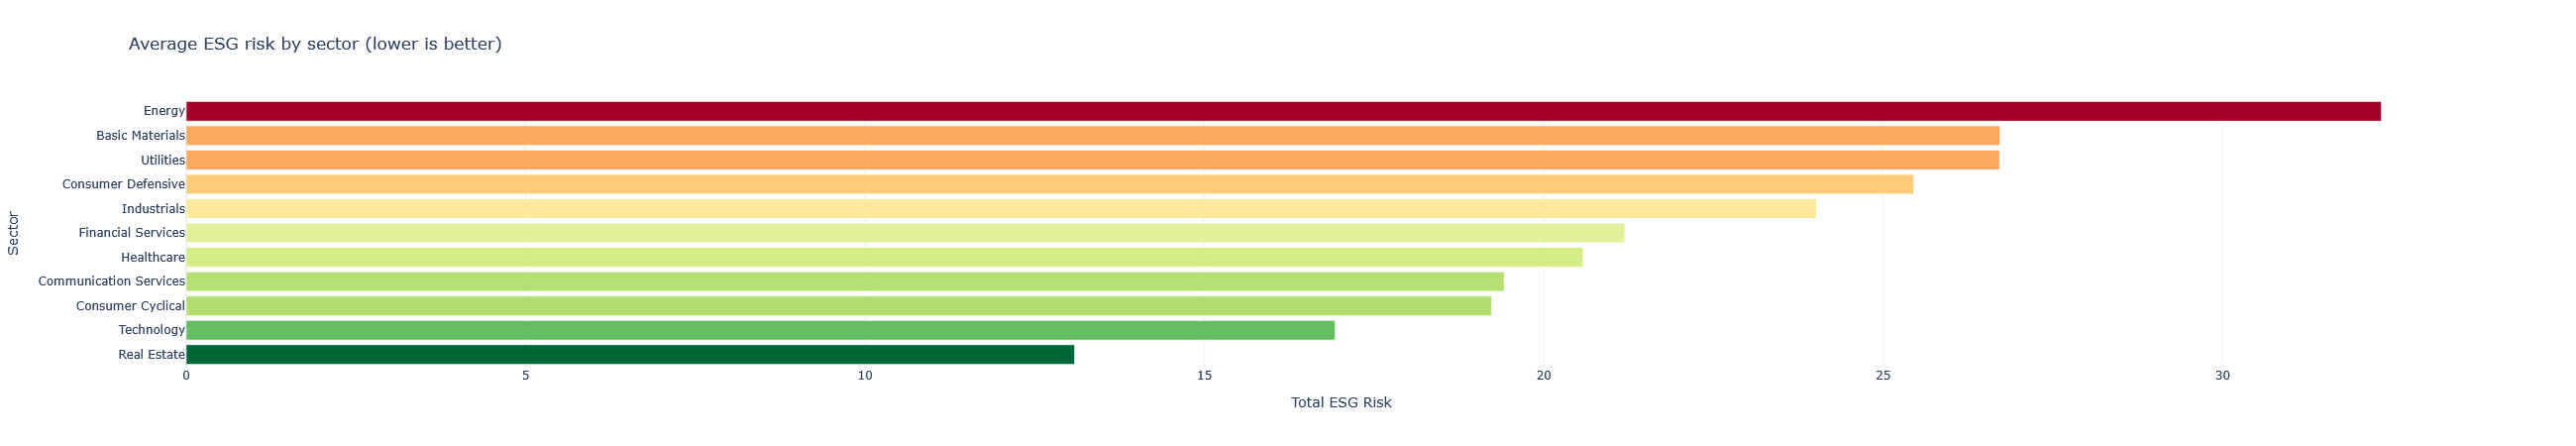

In [96]:
by_sector = (scored.groupby("Sector")["Total ESG Risk"]
                   .mean().sort_values().reset_index())

fig = px.bar(by_sector, x="Total ESG Risk", y="Sector", orientation="h",
             color="Total ESG Risk", color_continuous_scale="RdYlGn_r",
             title="Average ESG risk by sector (lower is better)")
fig.update_layout(height=450, coloraxis_showscale=False)
fig.show()

A mean hides the spread. A box plot shows the full distribution within each sector — note how wide some sectors are, meaning company choice matters as much as sector.

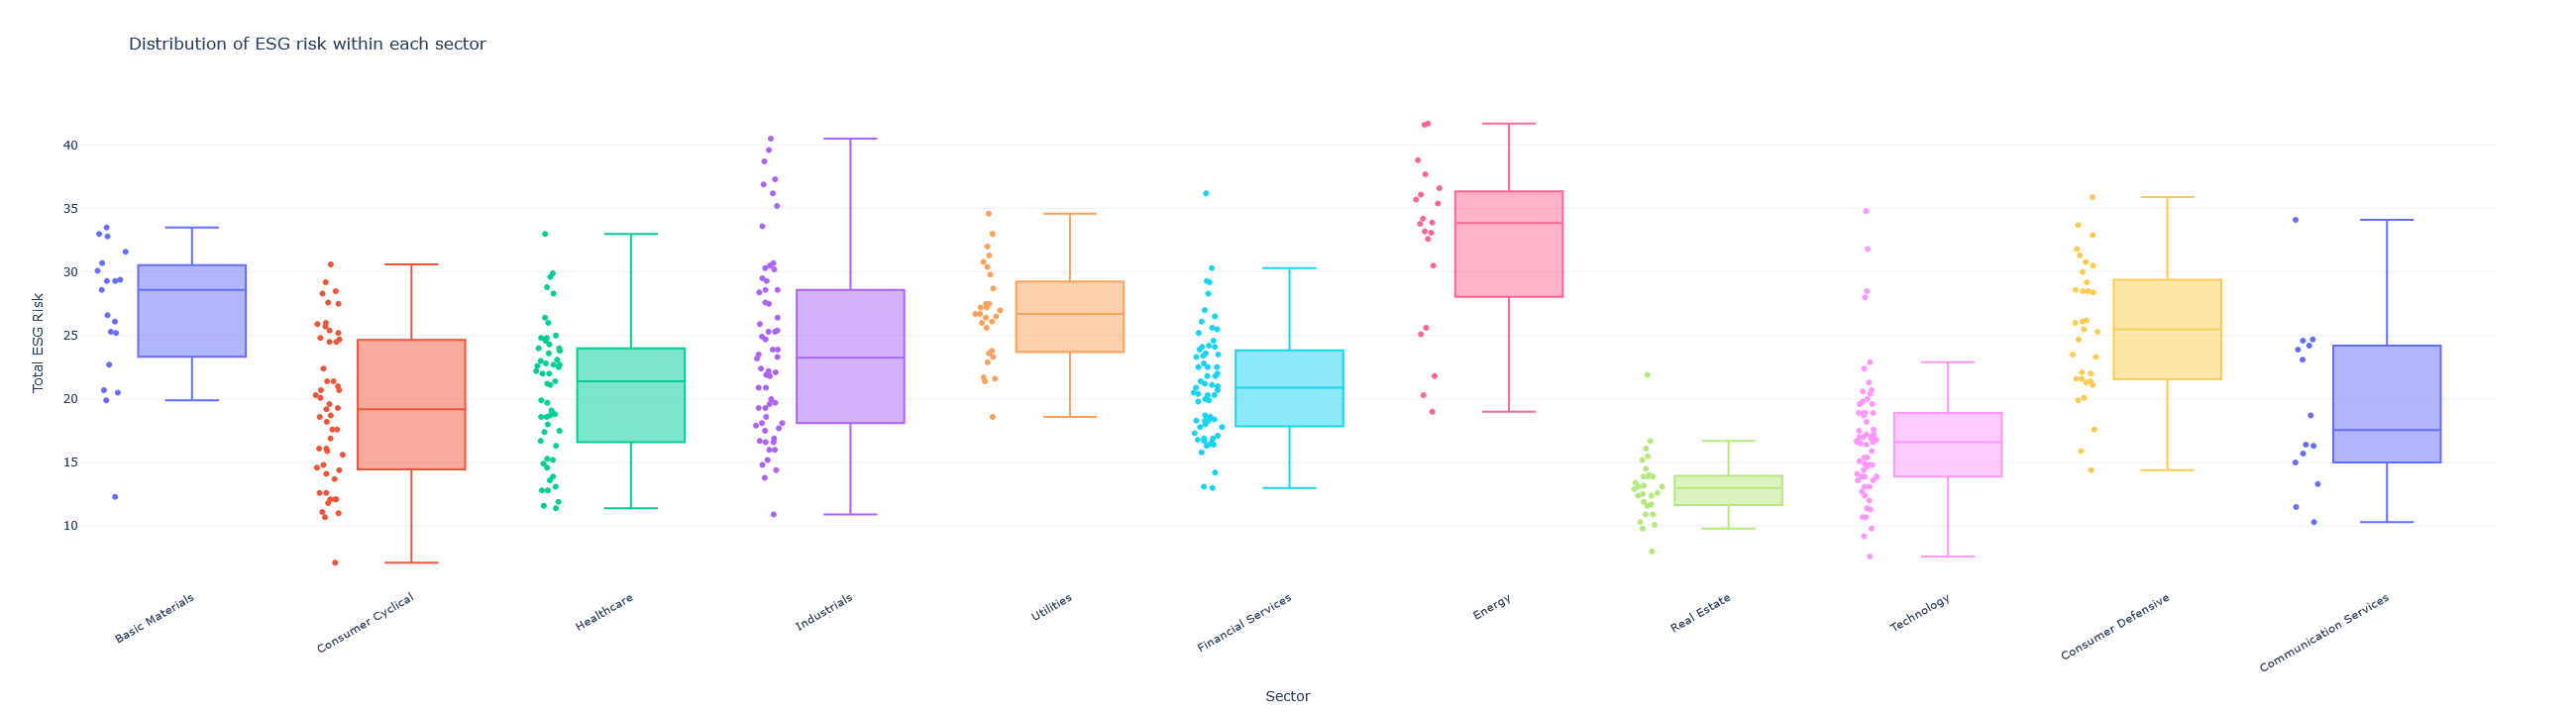

In [98]:
fig = px.box(scored, x="Sector", y="Total ESG Risk", color="Sector",
             points="all", hover_name="Company",
             title="Distribution of ESG risk within each sector")
fig.update_layout(height=720, showlegend=False, xaxis_tickangle=-30)
fig.show()

### An interactive sector explorer

Pick a sector from the dropdown and the chart redraws its companies' E/S/G breakdown. *(This needs a running kernel — `ipywidgets` renders live, not in a static preview.)*

In [100]:
try:
    import ipywidgets as widgets

    sectors = sorted(scored["Sector"].dropna().unique())

    def show_sector(sector):
        d = scored[scored["Sector"] == sector].sort_values("Total ESG Risk")
        fig = px.bar(d, x="Symbol", y=esg_cols, barmode="group",
                     title=f"E / S / G risk by company \u2014 {sector}",
                     labels={"value": "Risk score (lower is better)", "variable": "Pillar"})
        fig.update_layout(height=760)
        fig.show()

    widgets.interact(show_sector,
                     sector=widgets.Dropdown(options=sectors,
                             value="Technology" if "Technology" in sectors else sectors[0],
                             description="Sector:"))
except Exception as e:
    print("ipywidgets unavailable here; run `pip install ipywidgets`. Error:", e)

interactive(children=(Dropdown(description='Sector:', index=9, options=('Basic Materials', 'Communication Serv…

### Ranked pillar comparison (a callback to the original notebook)

The same three-panel `make_subplots` layout from our Yahoo example — each pillar sorted independently — but now for a sector of your choosing.

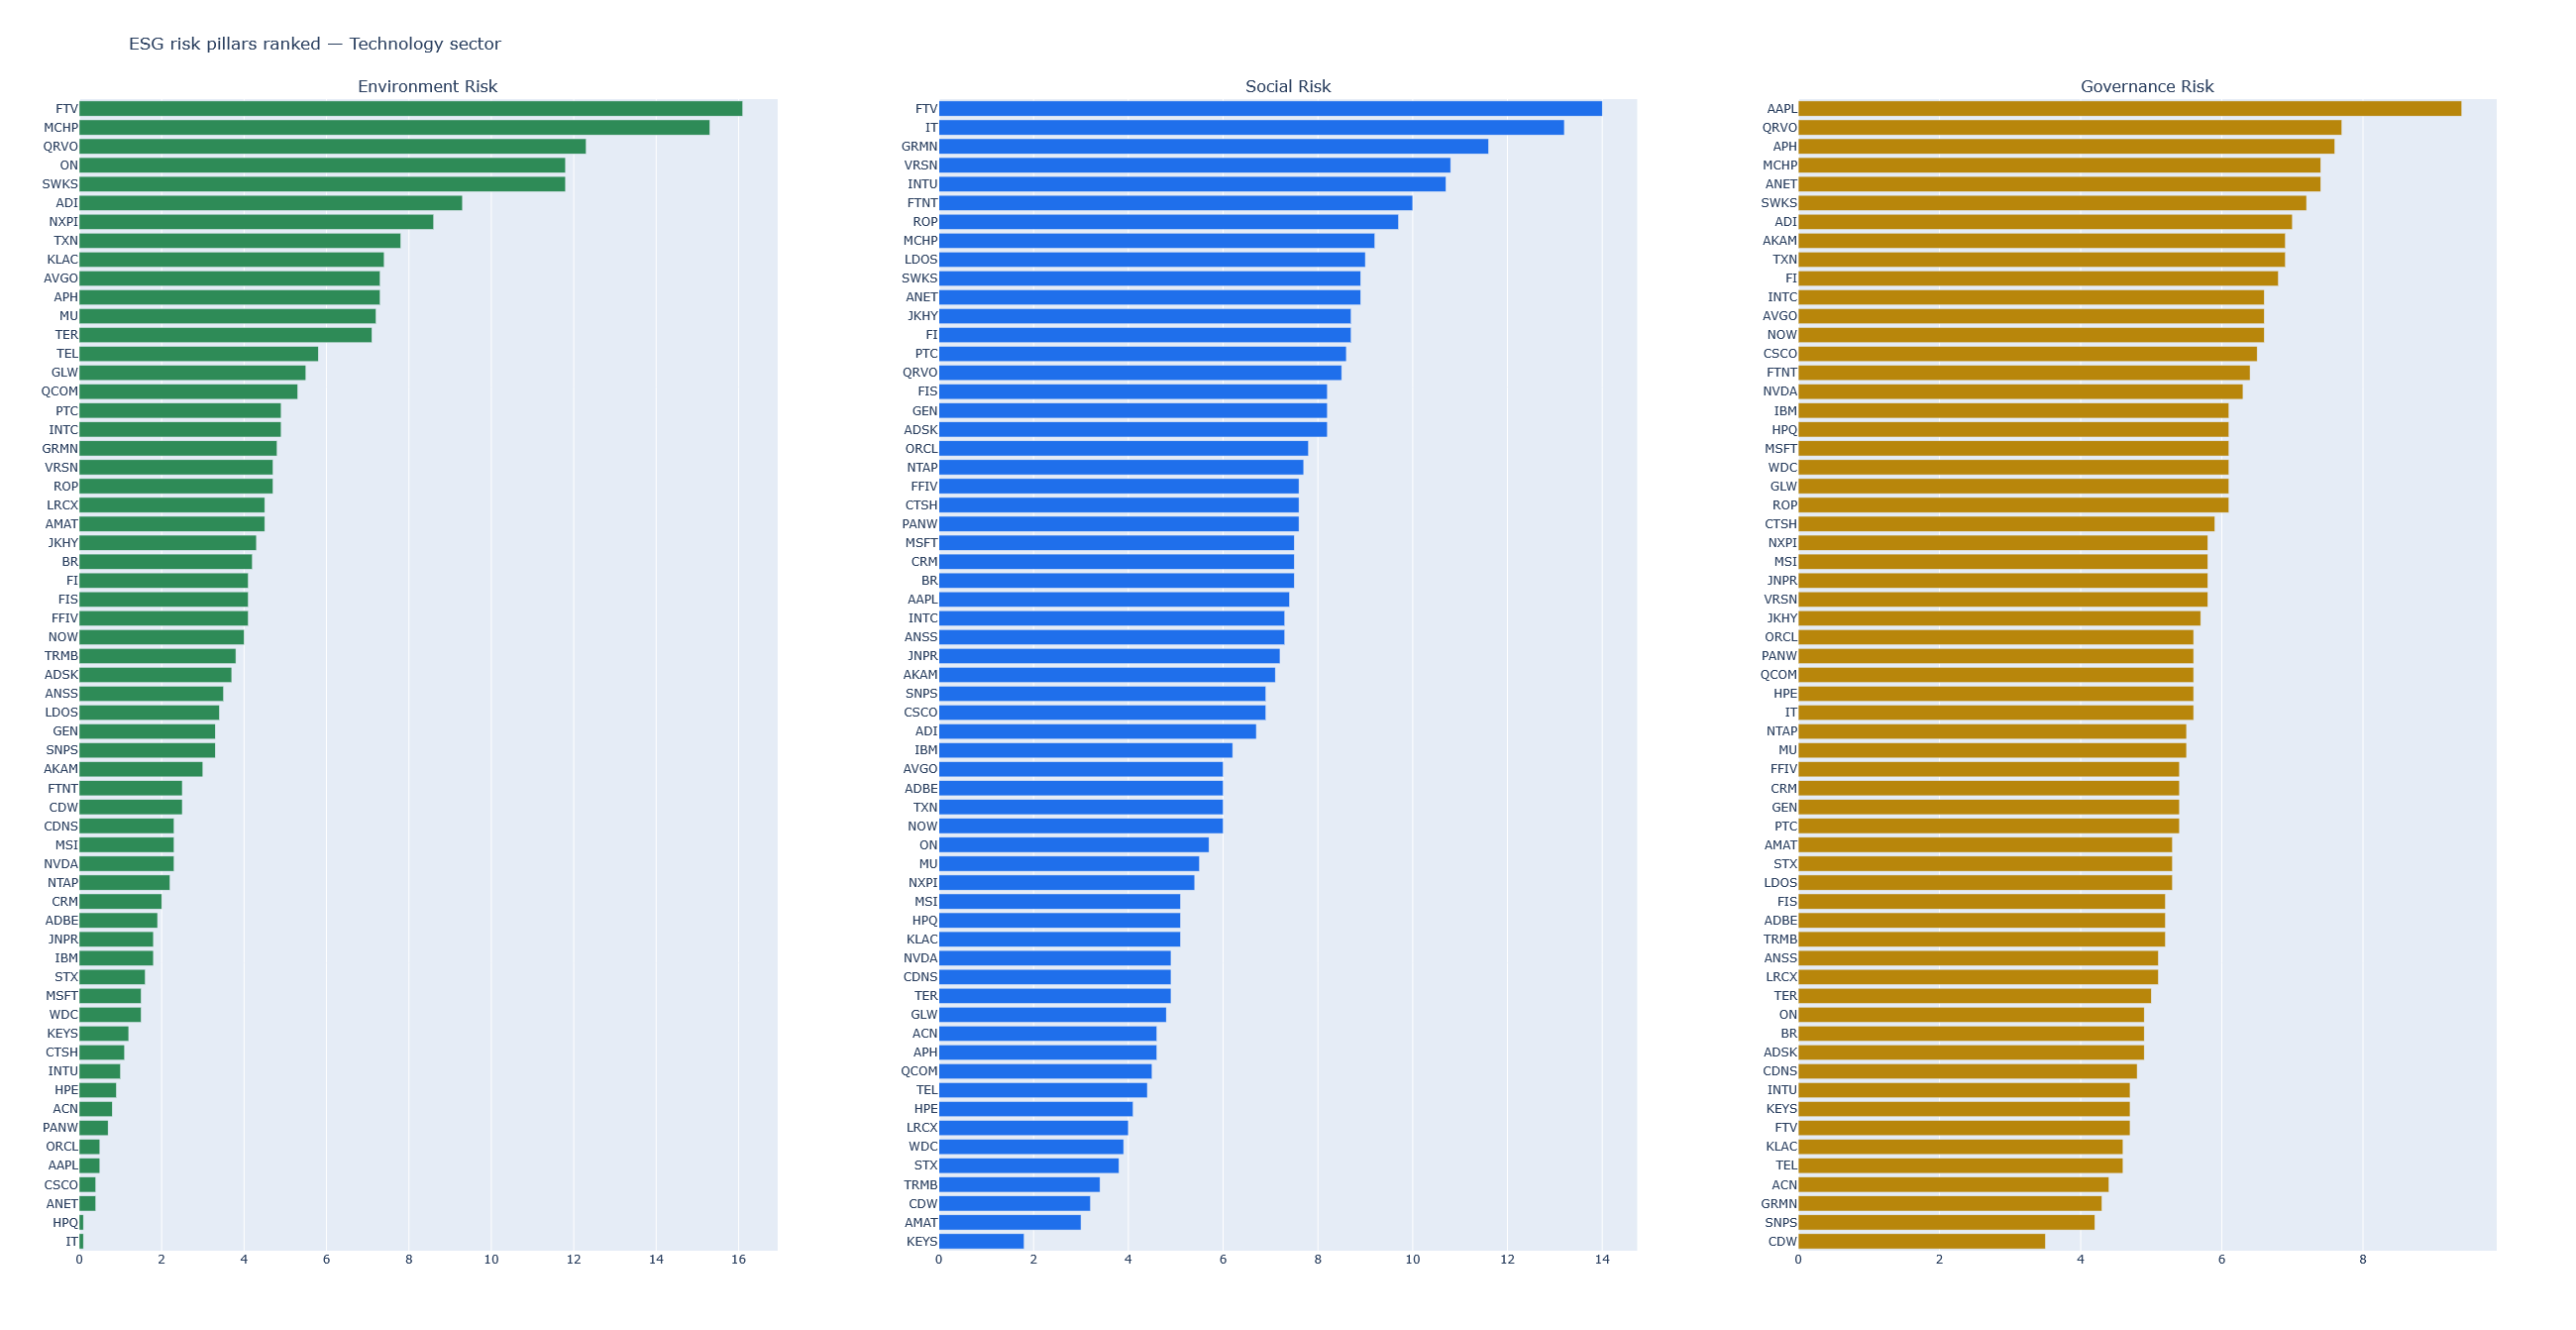

In [101]:
sector = "Technology"
d = scored[scored["Sector"] == sector]

fig = make_subplots(rows=1, cols=3, subplot_titles=esg_cols)
colours = {"Environment Risk": "#2E8B57", "Social Risk": "#1F6FEB", "Governance Risk": "#B8860B"}
for i, c in enumerate(esg_cols, start=1):
    ds = d.sort_values(c)
    fig.add_trace(go.Bar(x=ds[c], y=ds["Symbol"], orientation="h",
                         marker_color=colours[c], name=c), row=1, col=i)

fig.update_layout(height=max(400, 22 * len(d)), width=1000, showlegend=False,
                  title_text=f"ESG risk pillars ranked \u2014 {sector} sector")
fig.show()

### The classic 3D scatter, reborn

Our old three-dimensional ESG plot — each company placed by its E, S and G risk, sized by market cap, coloured by sector. Only companies with market-cap data appear here.

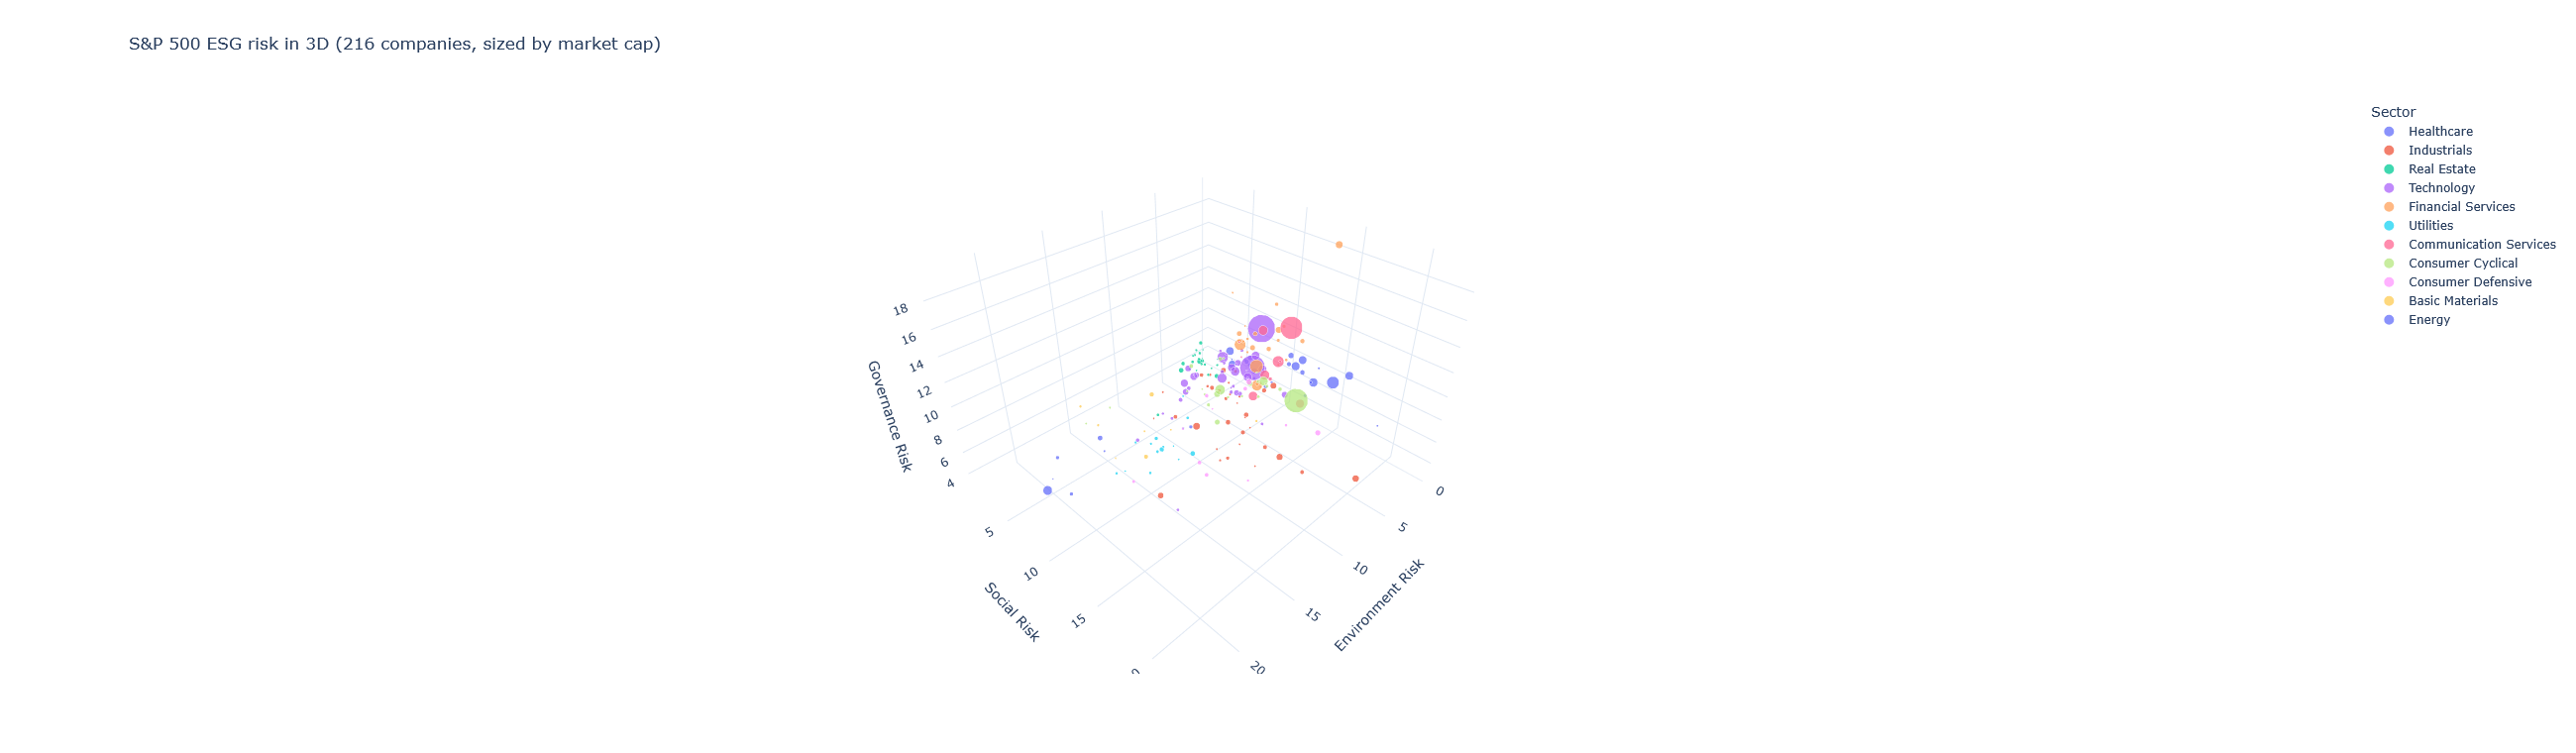

In [102]:
d3 = scored.dropna(subset=["Market Cap"])

fig = px.scatter_3d(d3, x="Environment Risk", y="Social Risk", z="Governance Risk",
                    color="Sector", size="Market Cap", size_max=45, opacity=0.75,
                    hover_name="Company",
                    title=f"S&P 500 ESG risk in 3D ({len(d3)} companies, sized by market cap)")
fig.update_layout(height=760)
fig.show()

### The whole index at a glance: a treemap

A treemap packs all ~430 scored companies into their sectors, sized by **workforce** and coloured by ESG risk. Big <span style="color:#AC0000;">red</span> tiles are large, higher-risk employers; big <span style="color:#2E8B57;">green</span> tiles are large, lower-risk ones. Click a sector to zoom in.

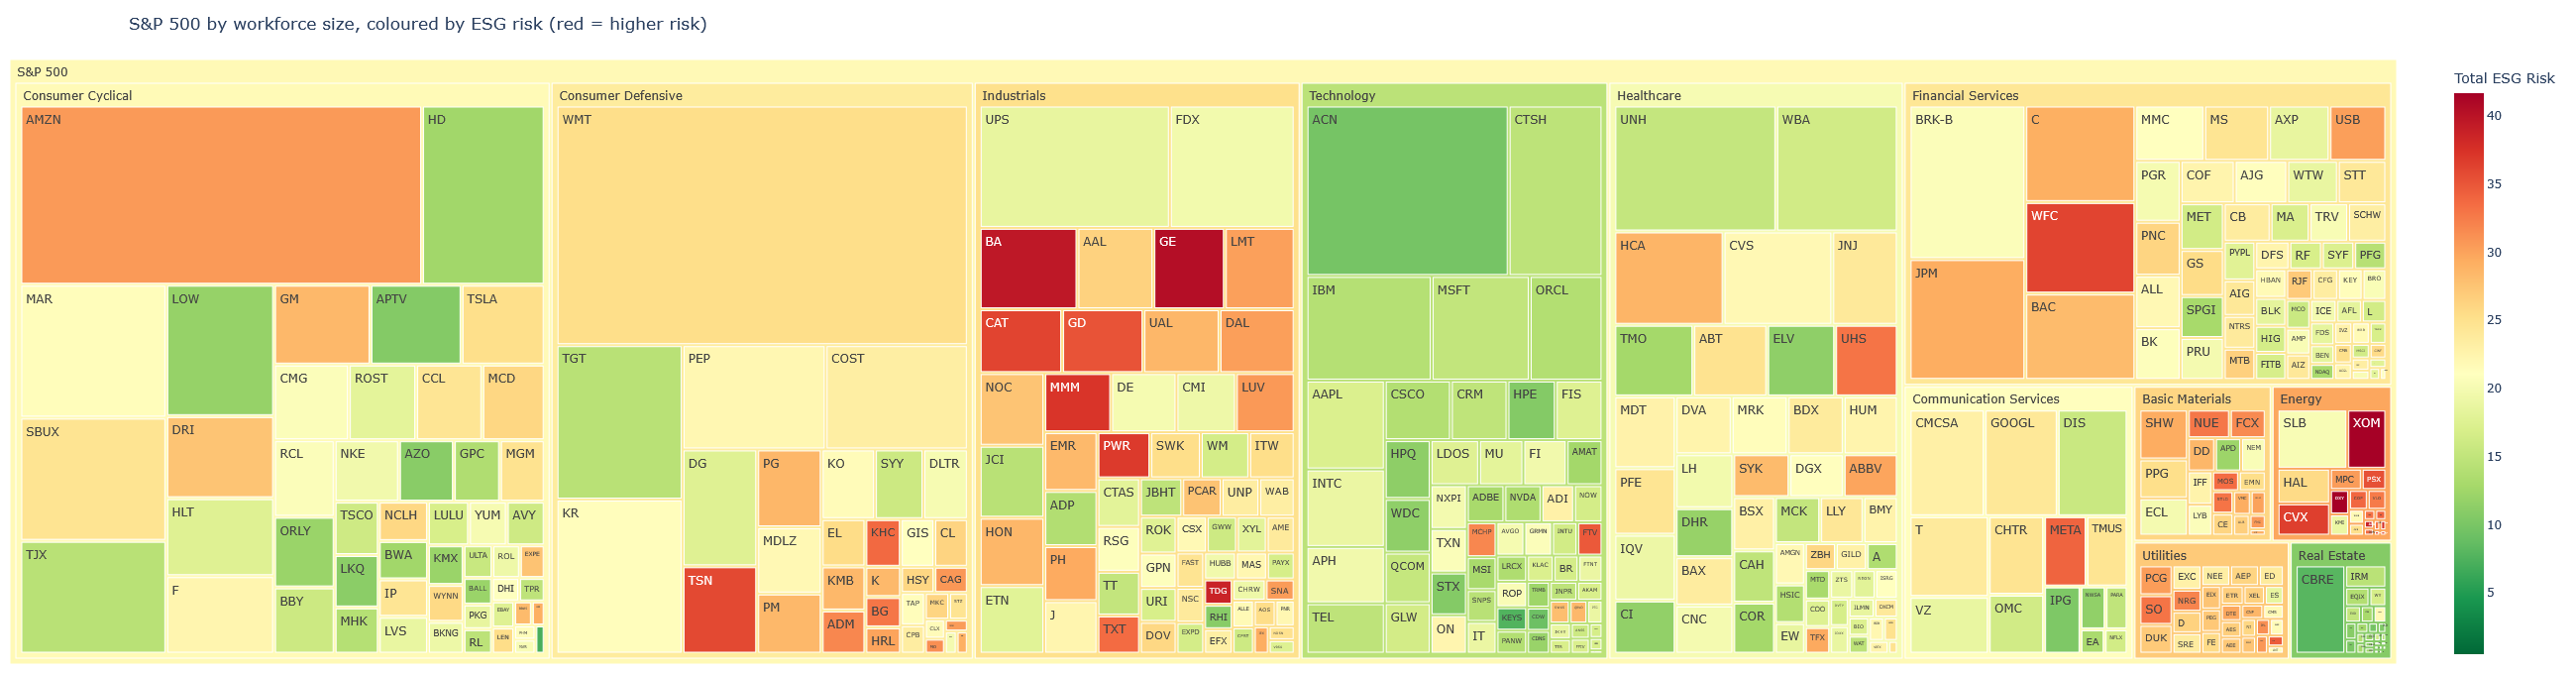

In [103]:
dt = scored.dropna(subset=["Employees"])

fig = px.treemap(dt, path=[px.Constant("S&P 500"), "Sector", "Symbol"],
                 values="Employees", color="Total ESG Risk",
                 color_continuous_scale="RdYlGn_r",
                 color_continuous_midpoint=dt["Total ESG Risk"].median(),
                 hover_data={"Company": True, "Total ESG Risk": ":.1f"},
                 title="S&P 500 by workforce size, coloured by ESG risk (red = higher risk)")
fig.update_layout(height=680, margin=dict(t=60, l=10, r=10, b=10))
fig.show()

### A map: where is ESG risk concentrated?

We parsed each company's headquarters **state** from its address, so we can draw a US choropleth of average ESG risk. Hover to see how many S&amp;P 500 companies each state hosts.

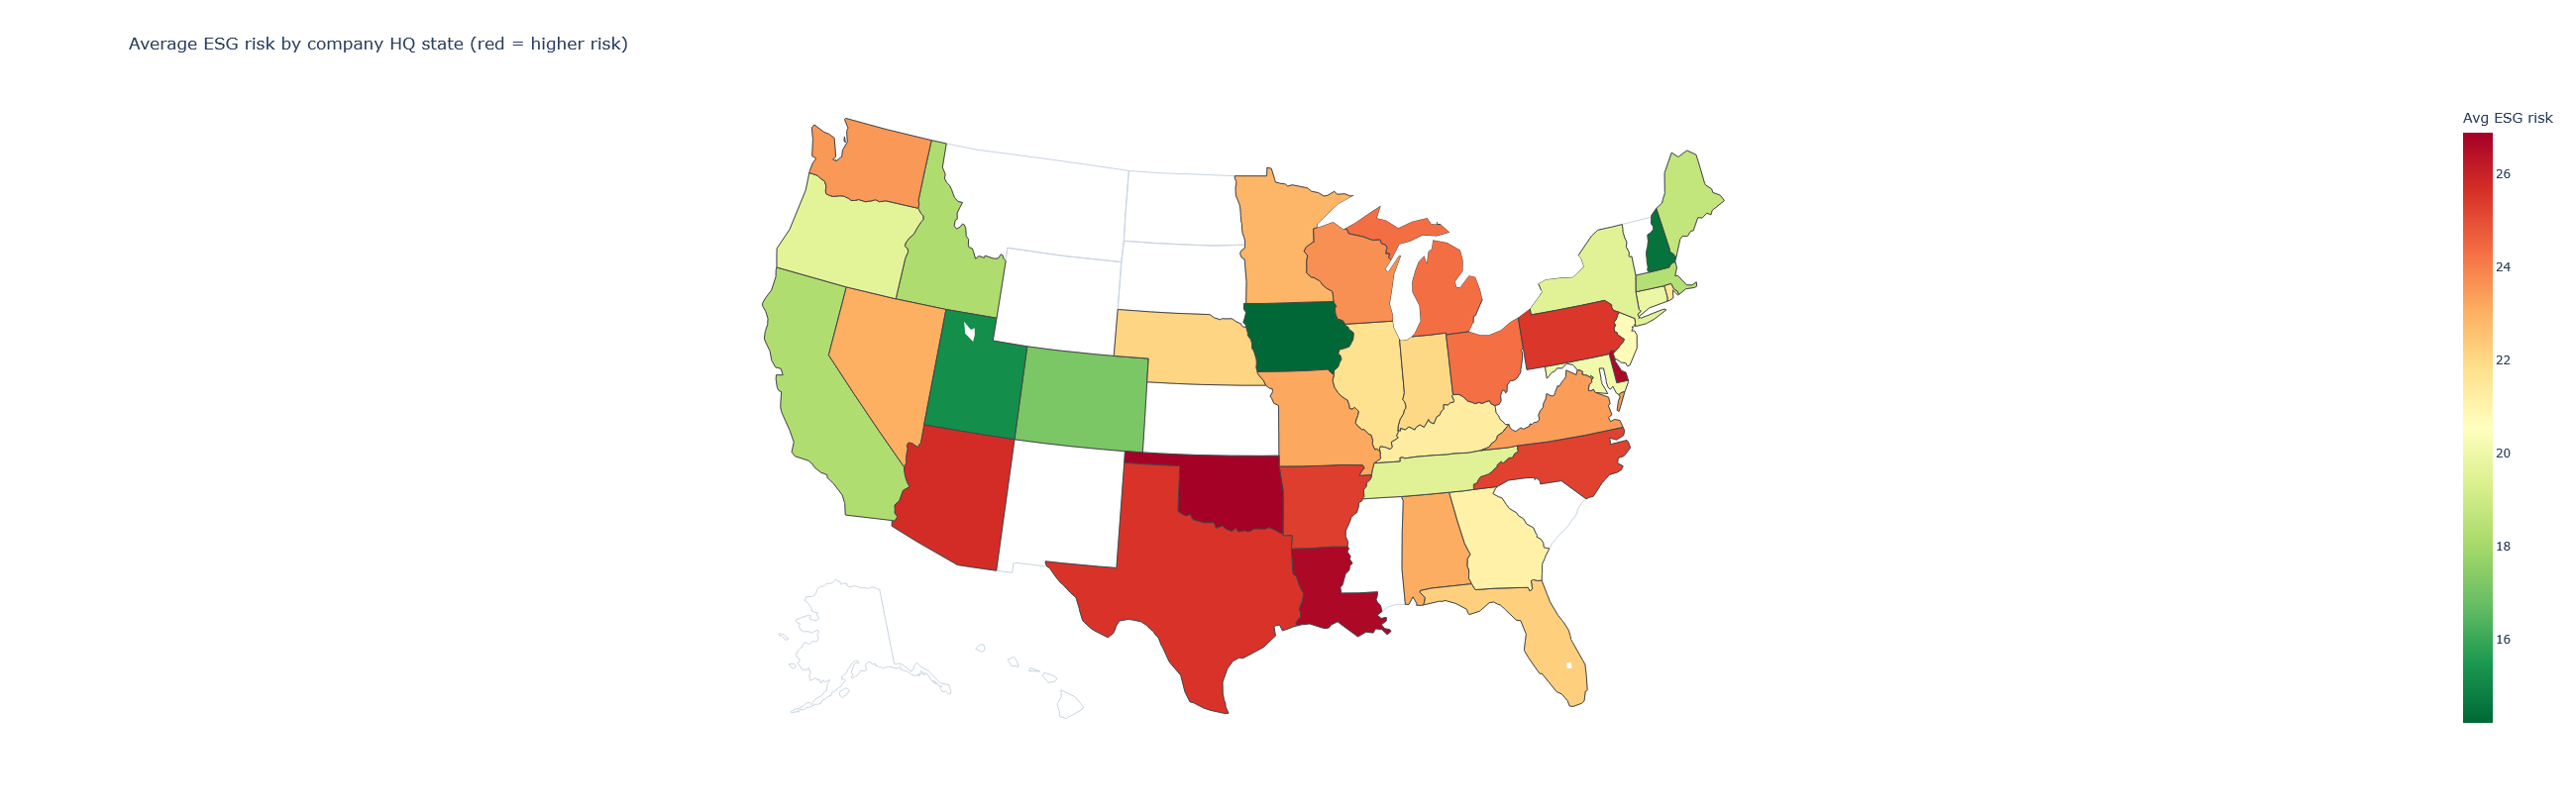

In [105]:
by_state = (df.dropna(subset=["State", "Total ESG Risk"])
              .groupby("State")
              .agg(avg_risk=("Total ESG Risk", "mean"), companies=("Symbol", "count"))
              .reset_index())

fig = px.choropleth(by_state, locations="State", locationmode="USA-states", scope="usa",
                    color="avg_risk", color_continuous_scale="RdYlGn_r",
                    hover_data={"companies": True, "avg_risk": ":.1f"},
                    labels={"avg_risk": "Avg ESG risk"},
                    title="Average ESG risk by company HQ state (red = higher risk)")
fig.update_layout(height=820)
fig.show()

### Controversies

Beyond scores, the dataset flags a **controversy level** per company. A sunburst shows how controversies distribute across sectors — click a ring to focus.

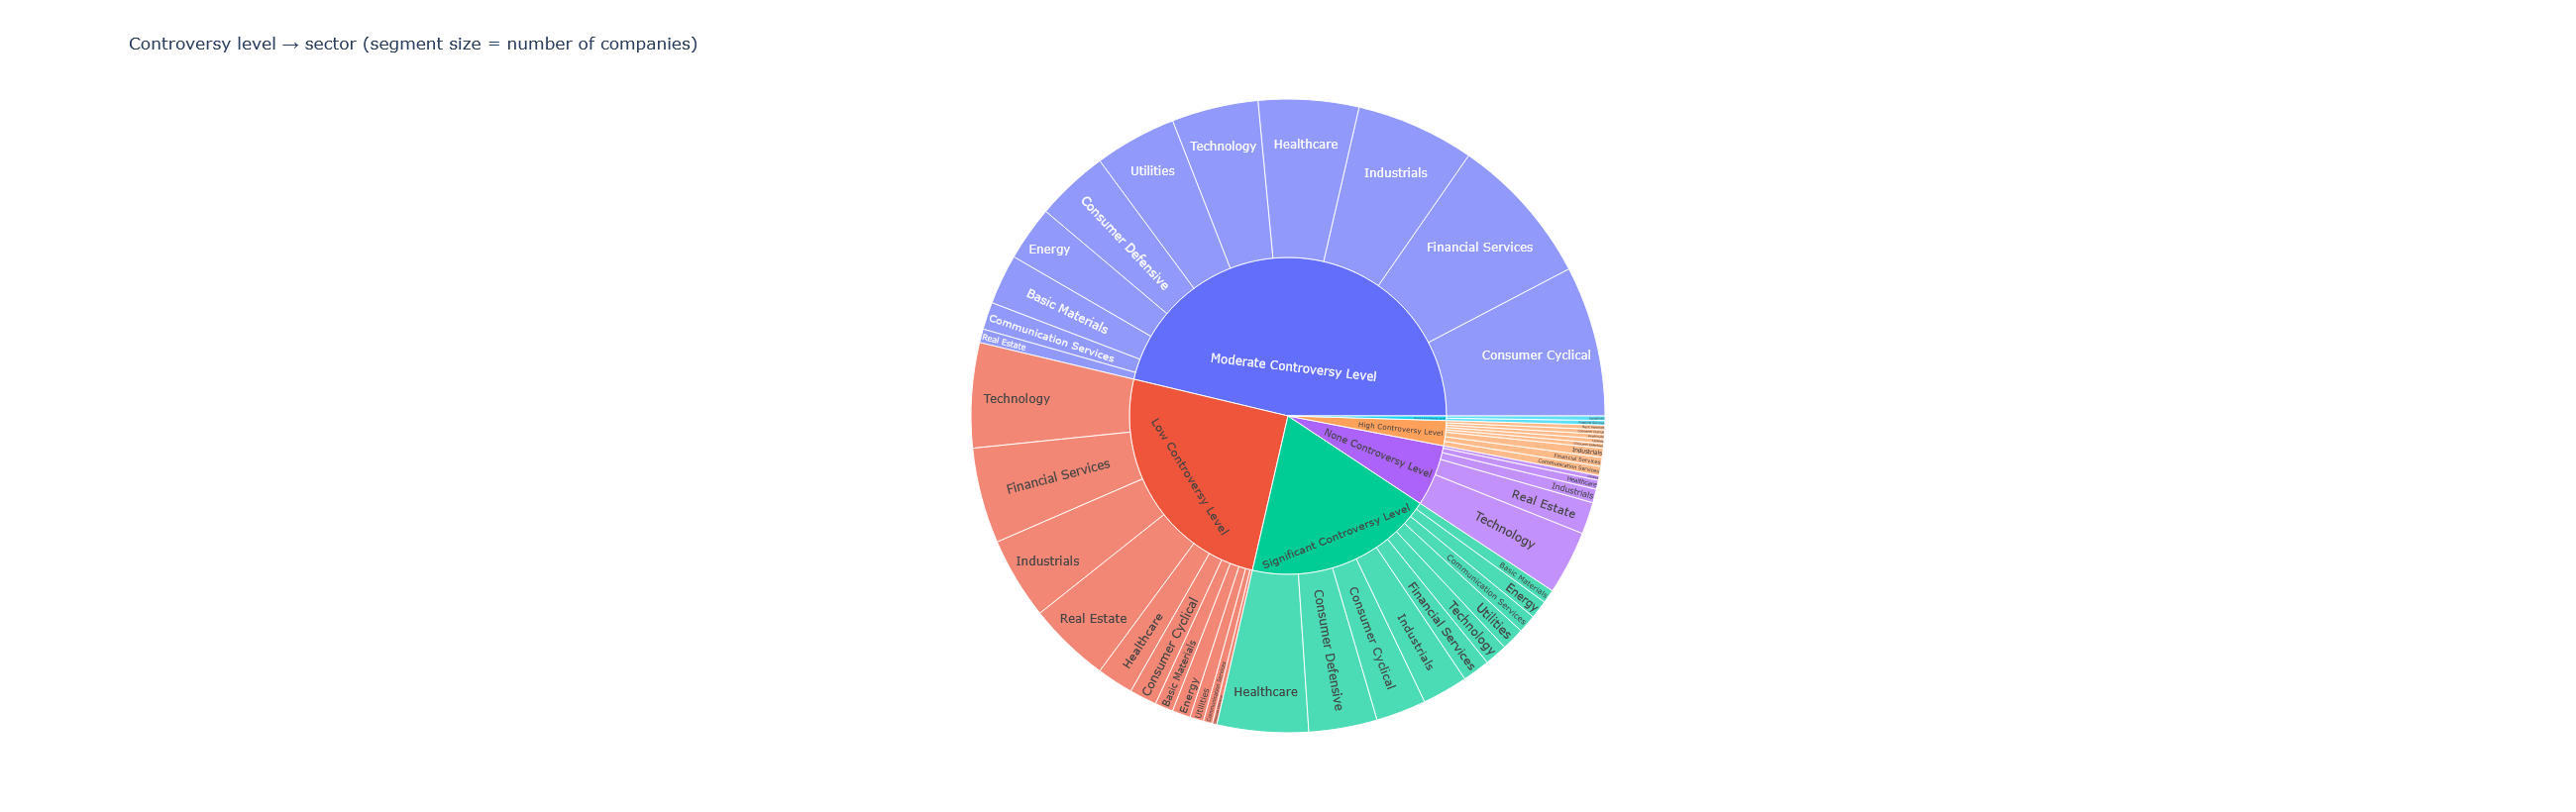

In [106]:
cc = df.dropna(subset=["Controversy Level"])

fig = px.sunburst(cc, path=["Controversy Level", "Sector"],
                  title="Controversy level \u2192 sector (segment size = number of companies)")
fig.update_layout(height=820)
fig.show()

**Act A recap.** With one static CSV we reproduced — and extended — the whole Yahoo lesson: styled tables, sector analysis, an interactive explorer, the 3D scatter, a treemap of the entire index, a US map, and controversy breakdowns. No keys, no rate limits, fully reproducible. The trade-off is that it is a **fixed snapshot**; for living data we turn to APIs.

---
# <span style="color:#8070FE;">Act B — World Bank ESG data</span>

The World Bank publishes a large, genuinely free ESG dataset — **no API key required** — through the friendly [`wbgapi`](https://pypi.org/project/wbgapi/) package. It is **country-level** rather than company-level, which makes it perfect for the big picture and, especially, for **maps**.

The Bank even maintains a dedicated **Environment, Social & Governance database** (database id `75`). We'll peek at its catalogue, then build some maps and the famous animated "wealth vs health" bubble chart.

In [ ]:
!pip install wbgapi # run only once!

✓ cache hit   → data\wb_life_expectancy.csv


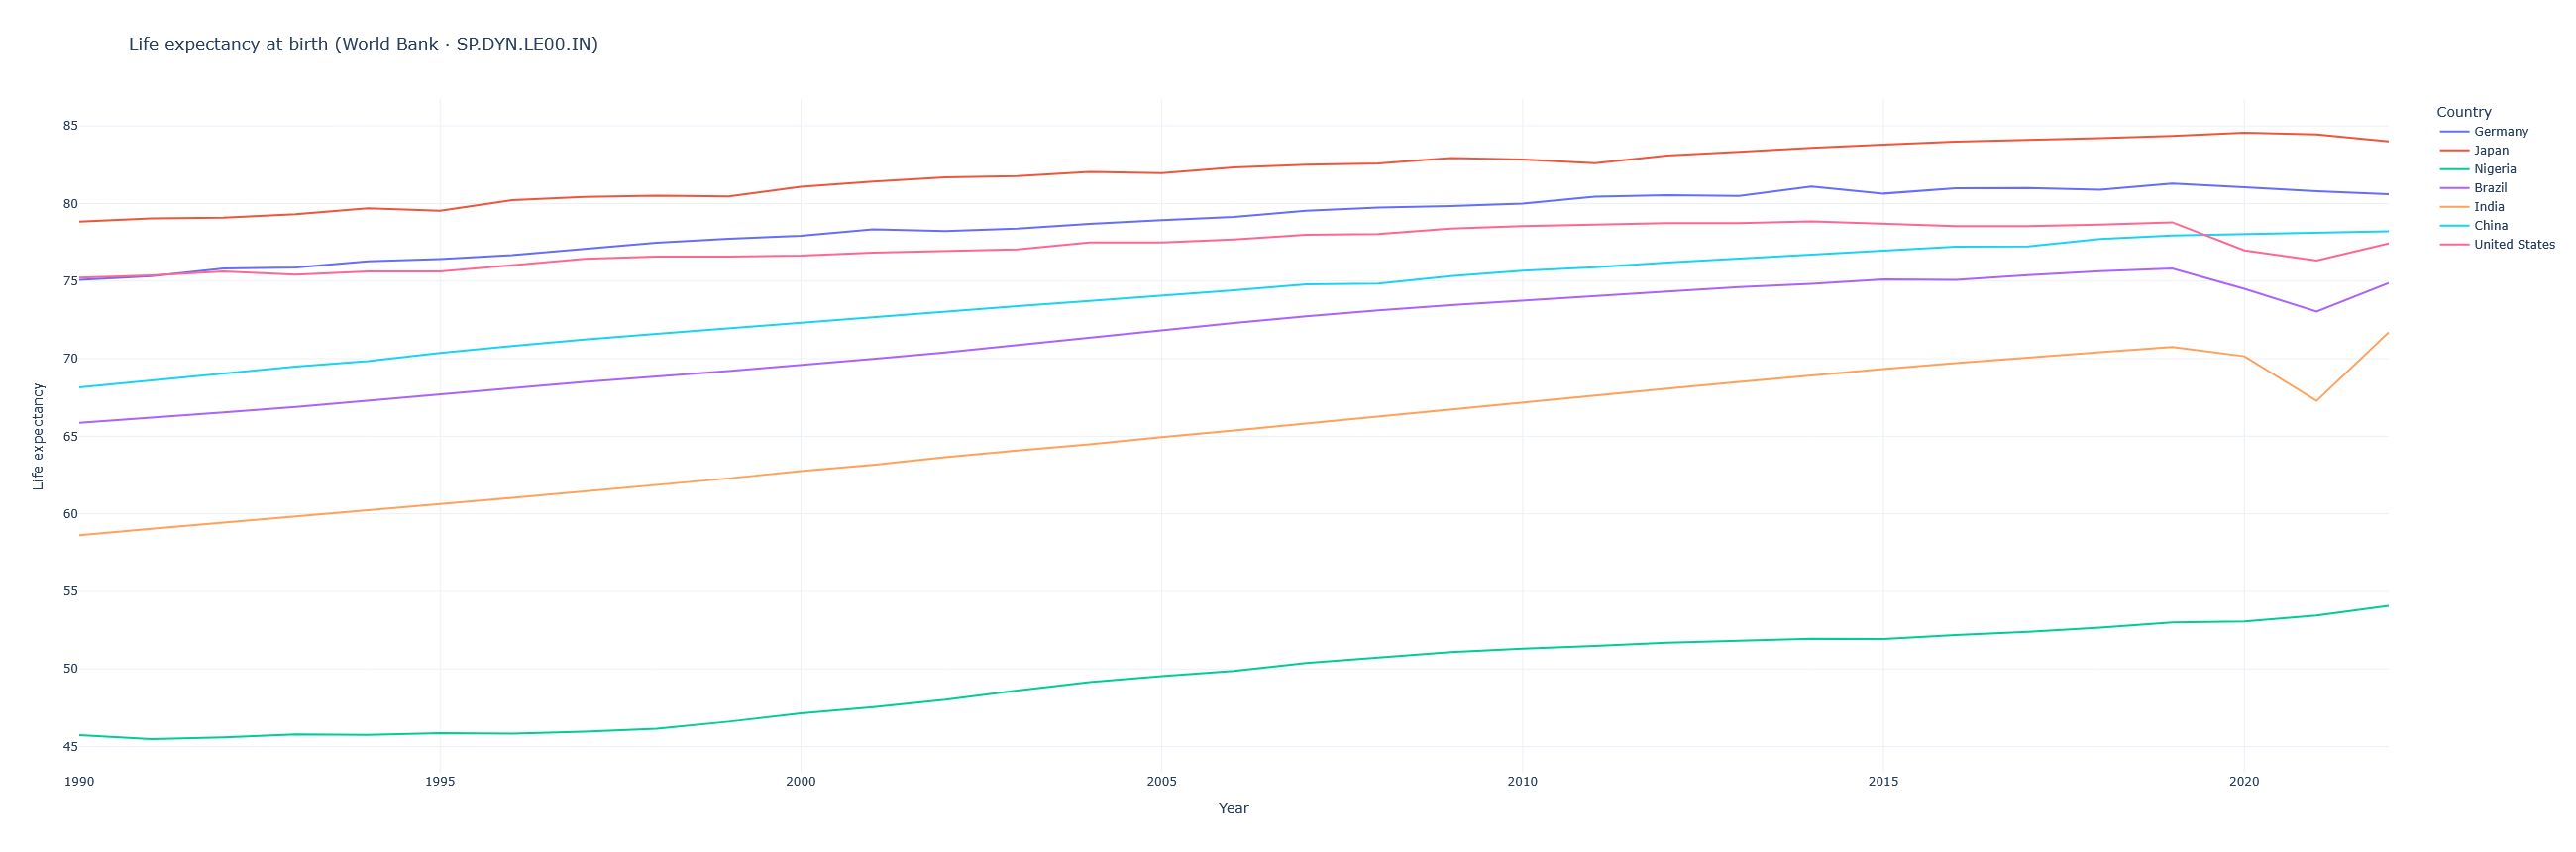

In [108]:
import wbgapi as wb
# wbgapi talks to the World Bank API directly; the default database (2) is the
# World Development Indicators. Codes like SP.DYN.LE00.IN identify indicators.

def fetch_life_expectancy():
    d = wb.data.DataFrame("SP.DYN.LE00.IN",
                          economy=["USA", "CHN", "IND", "BRA", "NGA", "JPN", "DEU"],
                          time=range(1990, 2023),
                          index=["economy", "time"], columns="series", # tidy long format
                          numericTimeKeys=True, labels=True, skipAggs=True)
    return d.reset_index()

le = load_or_fetch_csv("wb_life_expectancy.csv", fetch_life_expectancy)
le = le.rename(columns={"time": "Year", "SP.DYN.LE00.IN": "Life expectancy"})

fig = px.line(le, x="Year", y="Life expectancy", color="Country", markers=False,
              title="Life expectancy at birth (World Bank \u00b7 SP.DYN.LE00.IN)")
fig.update_layout(height=860)
fig.show()

### The dedicated ESG database

Switching to database `75` reveals the Bank's curated ESG indicator catalogue — dozens of measures spanning all three pillars, from emissions and renewable energy to schooling, and governance metrics such as control of corruption.

In [109]:
def fetch_esg_catalogue():
    wb.db = 75                                   # the ESG database
    rows = [(s.get("id"), s.get("value")) for s in wb.series.list()]
    wb.db = 2                                     # switch back to WDI for later fetches
    return pd.DataFrame(rows, columns=["Code", "Indicator"])

esg_catalogue = load_or_fetch_csv("wb_esg_catalogue.csv", fetch_esg_catalogue)
print(f"The World Bank ESG database lists {len(esg_catalogue)} indicators. A sample:")
esg_catalogue.head(20)

✓ cache hit   → data\wb_esg_catalogue.csv
The World Bank ESG database lists 80 indicators. A sample:


,Code,Indicator
0,AG.LND.AGRI.ZS,Agricultural land (% of land area)
1,AG.LND.FRLS.HA,Tree Cover Loss (hectares)
2,AG.LND.FRST.ZS,Forest area (% of land area)
3,AG.LND.PFLS.HA,Primary Forest Loss
4,AG.PRD.FOOD.XD,Food production index (2014-2016 = 100)
5,EG.CFT.ACCS.ZS,Access to clean fuels and technologies for coo...
6,EG.EGY.PRIM.PP.KD,Energy intensity level of primary energy (MJ/$...
7,EG.ELC.ACCS.RU.ZS,"Access to electricity, rural (% of rural popul..."
8,EG.ELC.ACCS.ZS,Access to electricity (% of population)
9,EG.ELC.COAL.ZS,Electricity production from coal sources (% of...


### Map 1 — renewable energy around the world

A world choropleth of **renewable energy consumption** (% of total final energy). `mrnev=1` asks for each country's most recent non-empty value. Countries relying most on renewables glow green.

✓ cache hit   → data\wb_renewables_latest.csv


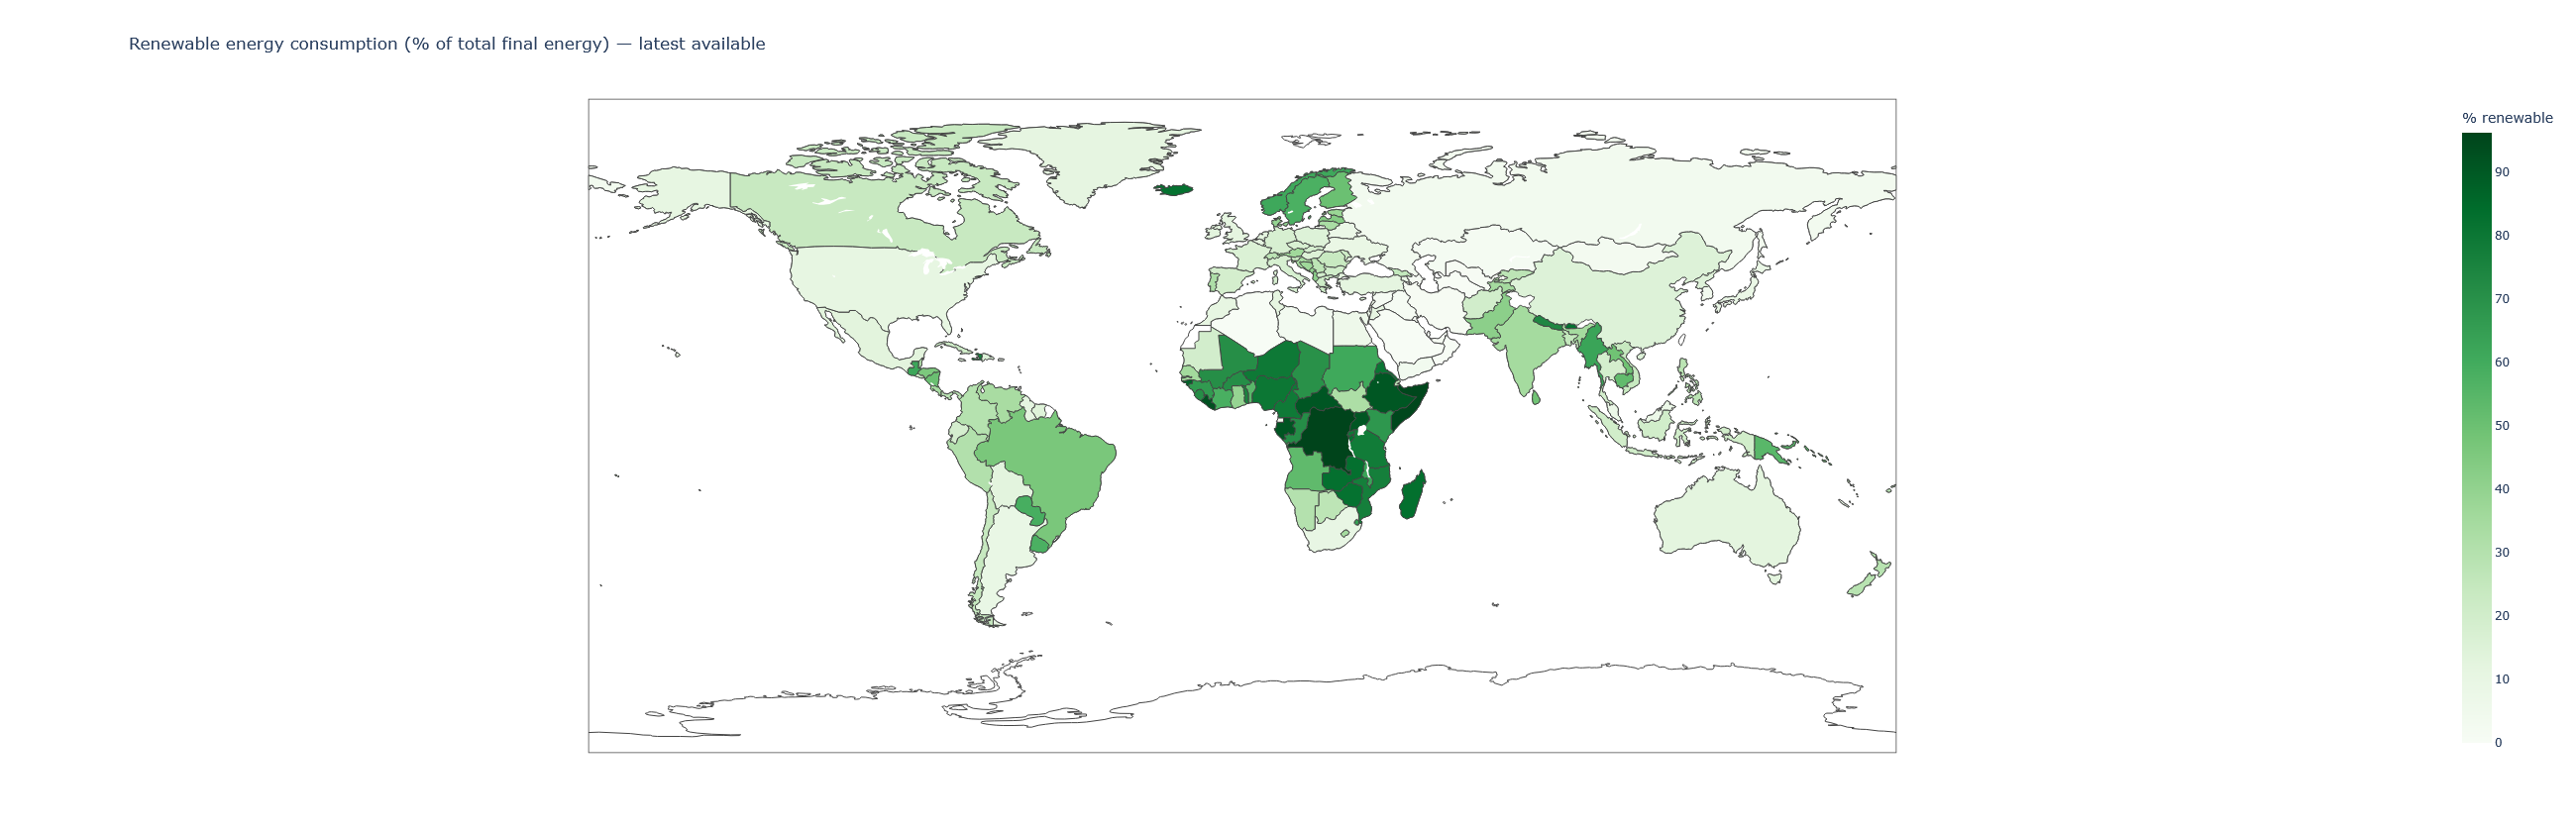

In [111]:
def fetch_renewables():
    d = wb.data.DataFrame("EG.FEC.RNEW.ZS", mrnev=1,
                          labels=True, skipAggs=True)
    return d.reset_index()

ren = load_or_fetch_csv("wb_renewables_latest.csv", fetch_renewables)

fig = px.choropleth(ren, locations="economy", locationmode="ISO-3",
                    color="EG.FEC.RNEW.ZS", hover_name="Country",
                    color_continuous_scale="Greens",
                    labels={"EG.FEC.RNEW.ZS": "% renewable"},
                    title="Renewable energy consumption (% of total final energy) \u2014 latest available")
fig.update_layout(height=840)
fig.show()

### Map 2 — CO&#8322; emissions over time (animated)

Now the fun one. We pull **CO&#8322; emissions per capita** for every country across ~25 years and let Plotly animate the map. Press play and watch the world's carbon footprint shift. (The colour scale is clipped at the 95th percentile so a few very high emitters don't wash out the rest.)

In [112]:
esg_catalogue[esg_catalogue["Code"].str.contains("CO2")]

,Code,Indicator
24,EN.GHG.CO2.LU.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - ...
25,EN.GHG.CO2.MT.CE.AR5,Carbon dioxide (CO2) emissions (total) excludi...


✓ cache hit   → data\wb_co2_timeseries.csv


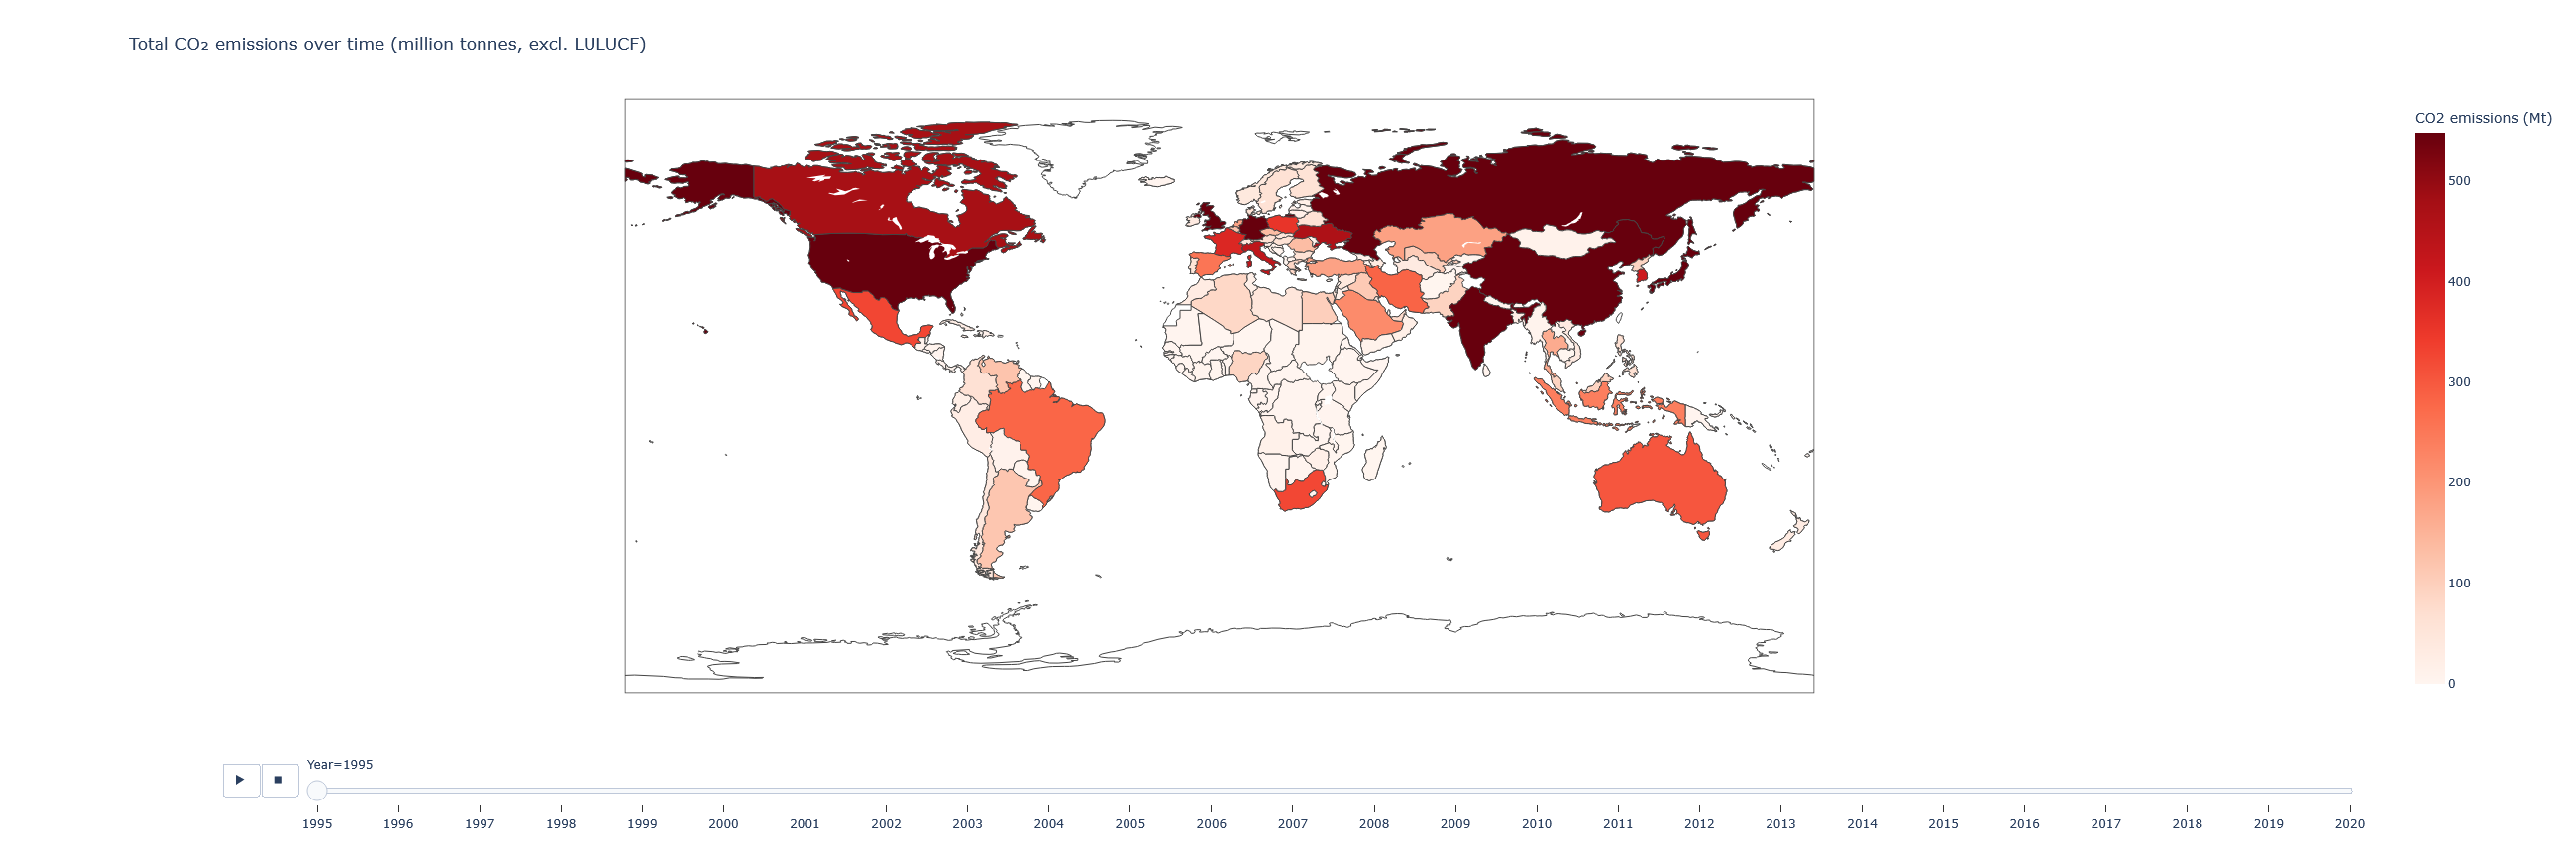

In [113]:
def fetch_co2_timeseries():
    d = wb.data.DataFrame("EN.GHG.CO2.MT.CE.AR5", time=range(1995, 2024),
                          index=["economy", "time"], columns="series",
                          numericTimeKeys=True, labels=True, skipAggs=True,
                          db=75)   # AR5 EDGAR-based emissions; lives in the ESG database
    return d.reset_index()

co2 = load_or_fetch_csv("wb_co2_timeseries.csv", fetch_co2_timeseries)
co2 = (co2.rename(columns={"time": "Year", "EN.GHG.CO2.MT.CE.AR5": "CO2 emissions (Mt)"})
          .dropna(subset=["CO2 emissions (Mt)"])
          .sort_values("Year"))

fig = px.choropleth(co2, locations="economy", locationmode="ISO-3",
                    color="CO2 emissions (Mt)", hover_name="Country",
                    animation_frame="Year", color_continuous_scale="Reds",
                    range_color=(0, co2["CO2 emissions (Mt)"].quantile(0.95)),
                    title="Total CO\u2082 emissions over time (million tonnes, excl. LULUCF)")
fig.update_layout(height=860)
fig.show()

✓ cache hit   → data\wb_co2_percapita.csv


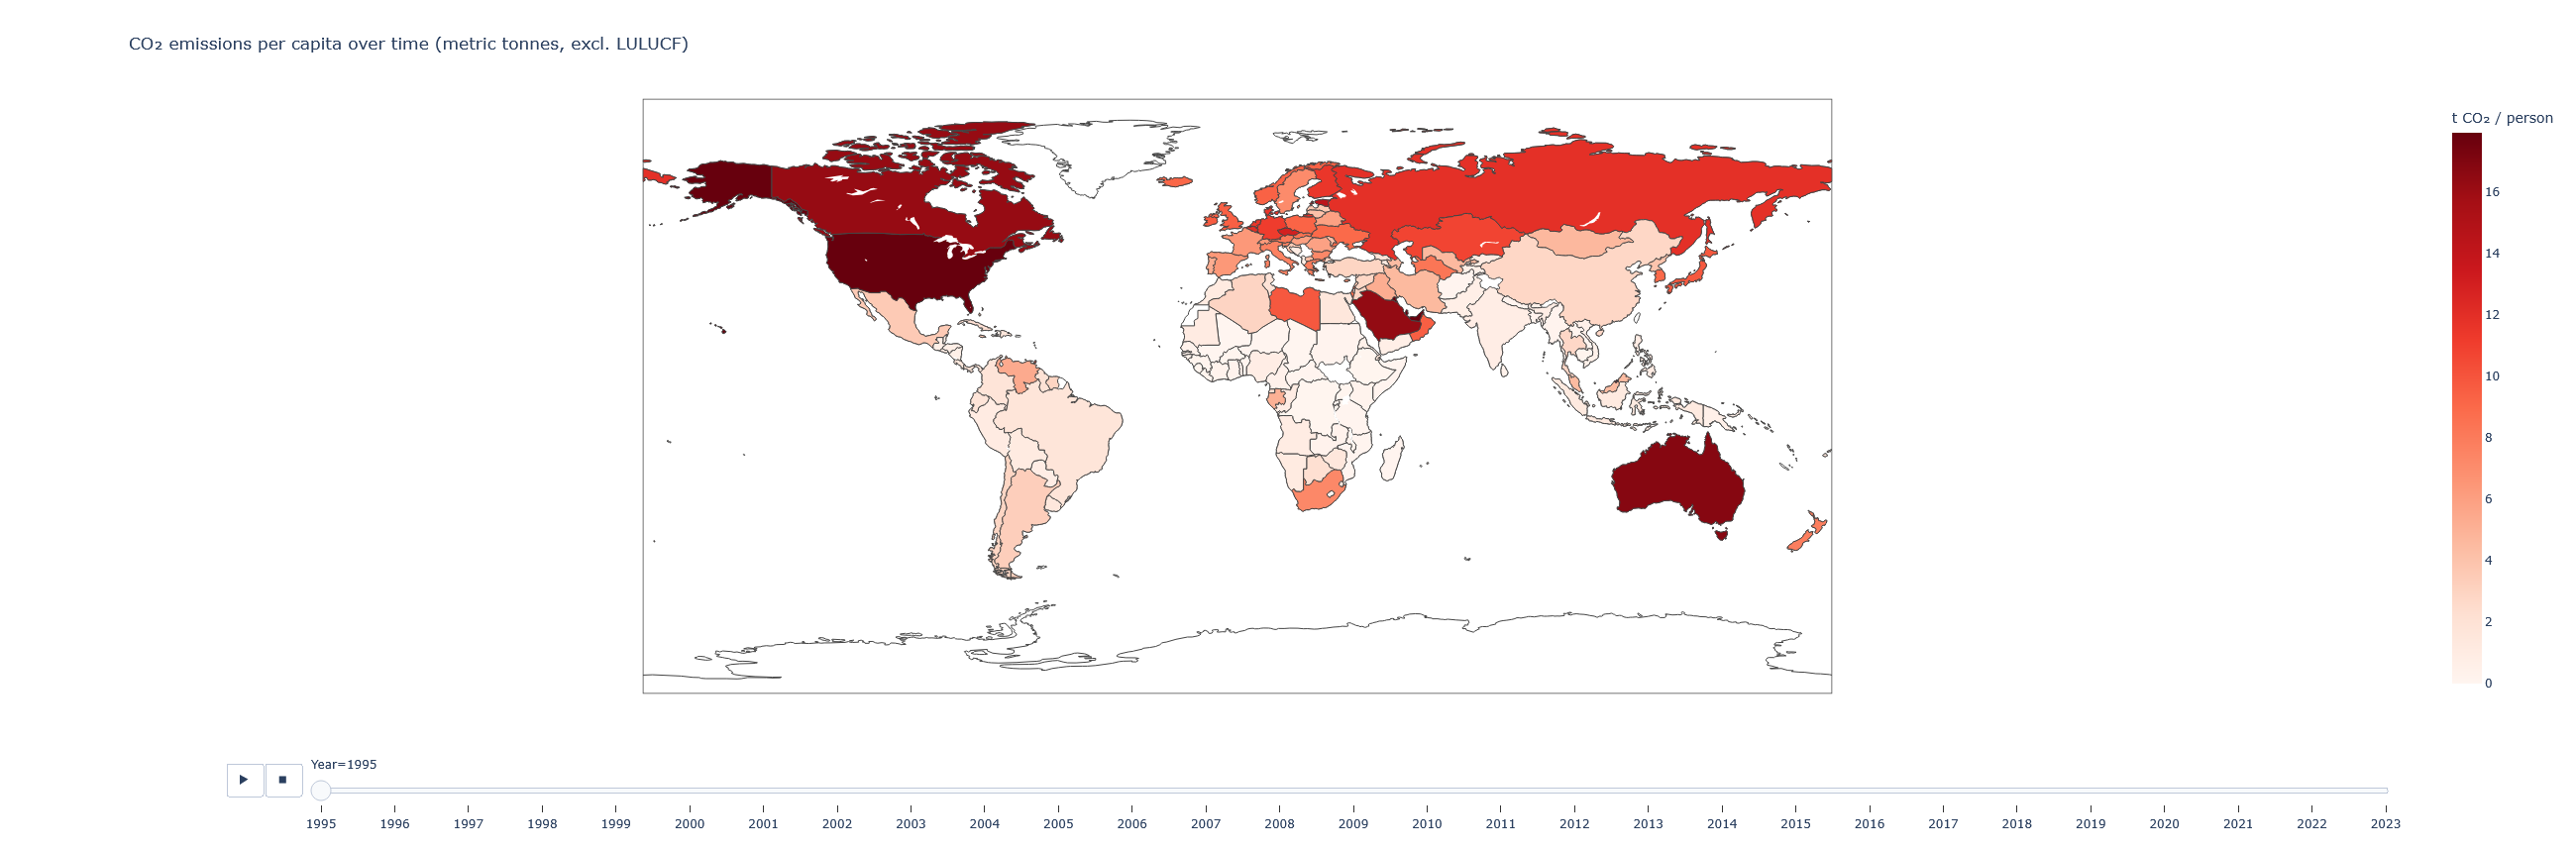

In [114]:
def fetch_co2_timeseries():
    co2 = wb.data.DataFrame("EN.GHG.CO2.MT.CE.AR5", time=range(1995, 2024),
                            index=["economy", "time"], columns="series",
                            numericTimeKeys=True, labels=True, skipAggs=True, db=75).reset_index()
    pop = wb.data.DataFrame("SP.POP.TOTL", time=range(1995, 2024),
                            index=["economy", "time"], columns="series",
                            numericTimeKeys=True, skipAggs=True).reset_index()   # population is in WDI
    m = co2.merge(pop, on=["economy", "time"])
    m["CO2 per capita"] = m["EN.GHG.CO2.MT.CE.AR5"] * 1e6 / m["SP.POP.TOTL"]     # Mt -> tonnes, per person
    return m[["economy", "time", "Country", "CO2 per capita"]]

co2 = load_or_fetch_csv("wb_co2_percapita.csv", fetch_co2_timeseries)
co2 = (co2.rename(columns={"time": "Year"})
          .dropna(subset=["CO2 per capita"])
          .sort_values("Year"))

fig = px.choropleth(co2, locations="economy", locationmode="ISO-3",
                    color="CO2 per capita", hover_name="Country",
                    animation_frame="Year", color_continuous_scale="Reds",
                    range_color=(0, co2["CO2 per capita"].quantile(0.95)),
                    labels={"CO2 per capita": "t CO\u2082 / person"},
                    title="CO\u2082 emissions per capita over time (metric tonnes, excl. LULUCF)")
fig.update_layout(height=860)
fig.show()

### The Gapminder view — wealth vs health, animated

Hans Rosling's famous chart, built live from World Bank data: **GDP per capita** (x, log scale) against **life expectancy** (y), each bubble a country sized by **population** and coloured by region. Press play to watch seven decades of development.

*(Plotly also ships this as a bundled offline dataset — `px.data.gapminder()` — handy if you ever want the chart without a connection.)*

In [ ]:
# from pathlib import Path
# Path("data/wb_regions.csv").unlink(missing_ok=True)   # force a clean re-fetch

In [115]:
def fetch_gapminder():
    codes = ["NY.GDP.PCAP.CD", "SP.DYN.LE00.IN", "SP.POP.TOTL"]
    d = wb.data.DataFrame(codes, time=range(1990, 2021),
                          index=["economy", "time"], columns="series",
                          numericTimeKeys=True, skipAggs=True)
    return d.reset_index()

def fetch_regions():
    e = wb.economy.DataFrame().reset_index().rename(columns={"id": "economy"})  # <-- key fix
    keep = [c for c in ["economy", "name", "region", "incomeLevel"] if c in e.columns]
    return e[keep]

gap = load_or_fetch_csv("wb_gapminder.csv", fetch_gapminder)
regions = load_or_fetch_csv("wb_regions.csv", fetch_regions)

g = (gap.merge(regions, on="economy", how="left")
        .rename(columns={"time": "Year", "NY.GDP.PCAP.CD": "GDP per capita",
                         "SP.DYN.LE00.IN": "Life expectancy", "SP.POP.TOTL": "Population"})
        .dropna(subset=["GDP per capita", "Life expectancy", "Population", "region"])
        .sort_values("Year"))

✓ cache hit   → data\wb_gapminder.csv
✓ cache hit   → data\wb_regions.csv


In [116]:
g

,economy,Year,GDP per capita,Life expectancy,Population,name,region,incomeLevel
0,ABW,1990,12187.536361,72.546000,62753.0,Aruba,LCN,HIC
1922,FIN,1990,28366.204276,74.813171,4986431.0,Finland,ECS,HIC
1891,ETH,1990,262.108971,45.117000,47609755.0,Ethiopia,SSF,LIC
6045,TTO,1990,4047.250936,67.591000,1252208.0,Trinidad and Tobago,LCN,HIC
1829,ESP,1990,13795.015939,76.837561,38867322.0,Spain,ECS,HIC
...,...,...,...,...,...,...,...,...
2107,GAB,2020,6605.803461,67.073000,2322539.0,Gabon,SSF,UMC
2138,GBR,2020,40815.125536,80.331756,66740000.0,United Kingdom,ECS,HIC
5951,TJK,2020,834.311715,68.605000,9749310.0,Tajikistan,ECS,LMC
1952,FIN,2020,48828.684686,81.931707,5529543.0,Finland,ECS,HIC


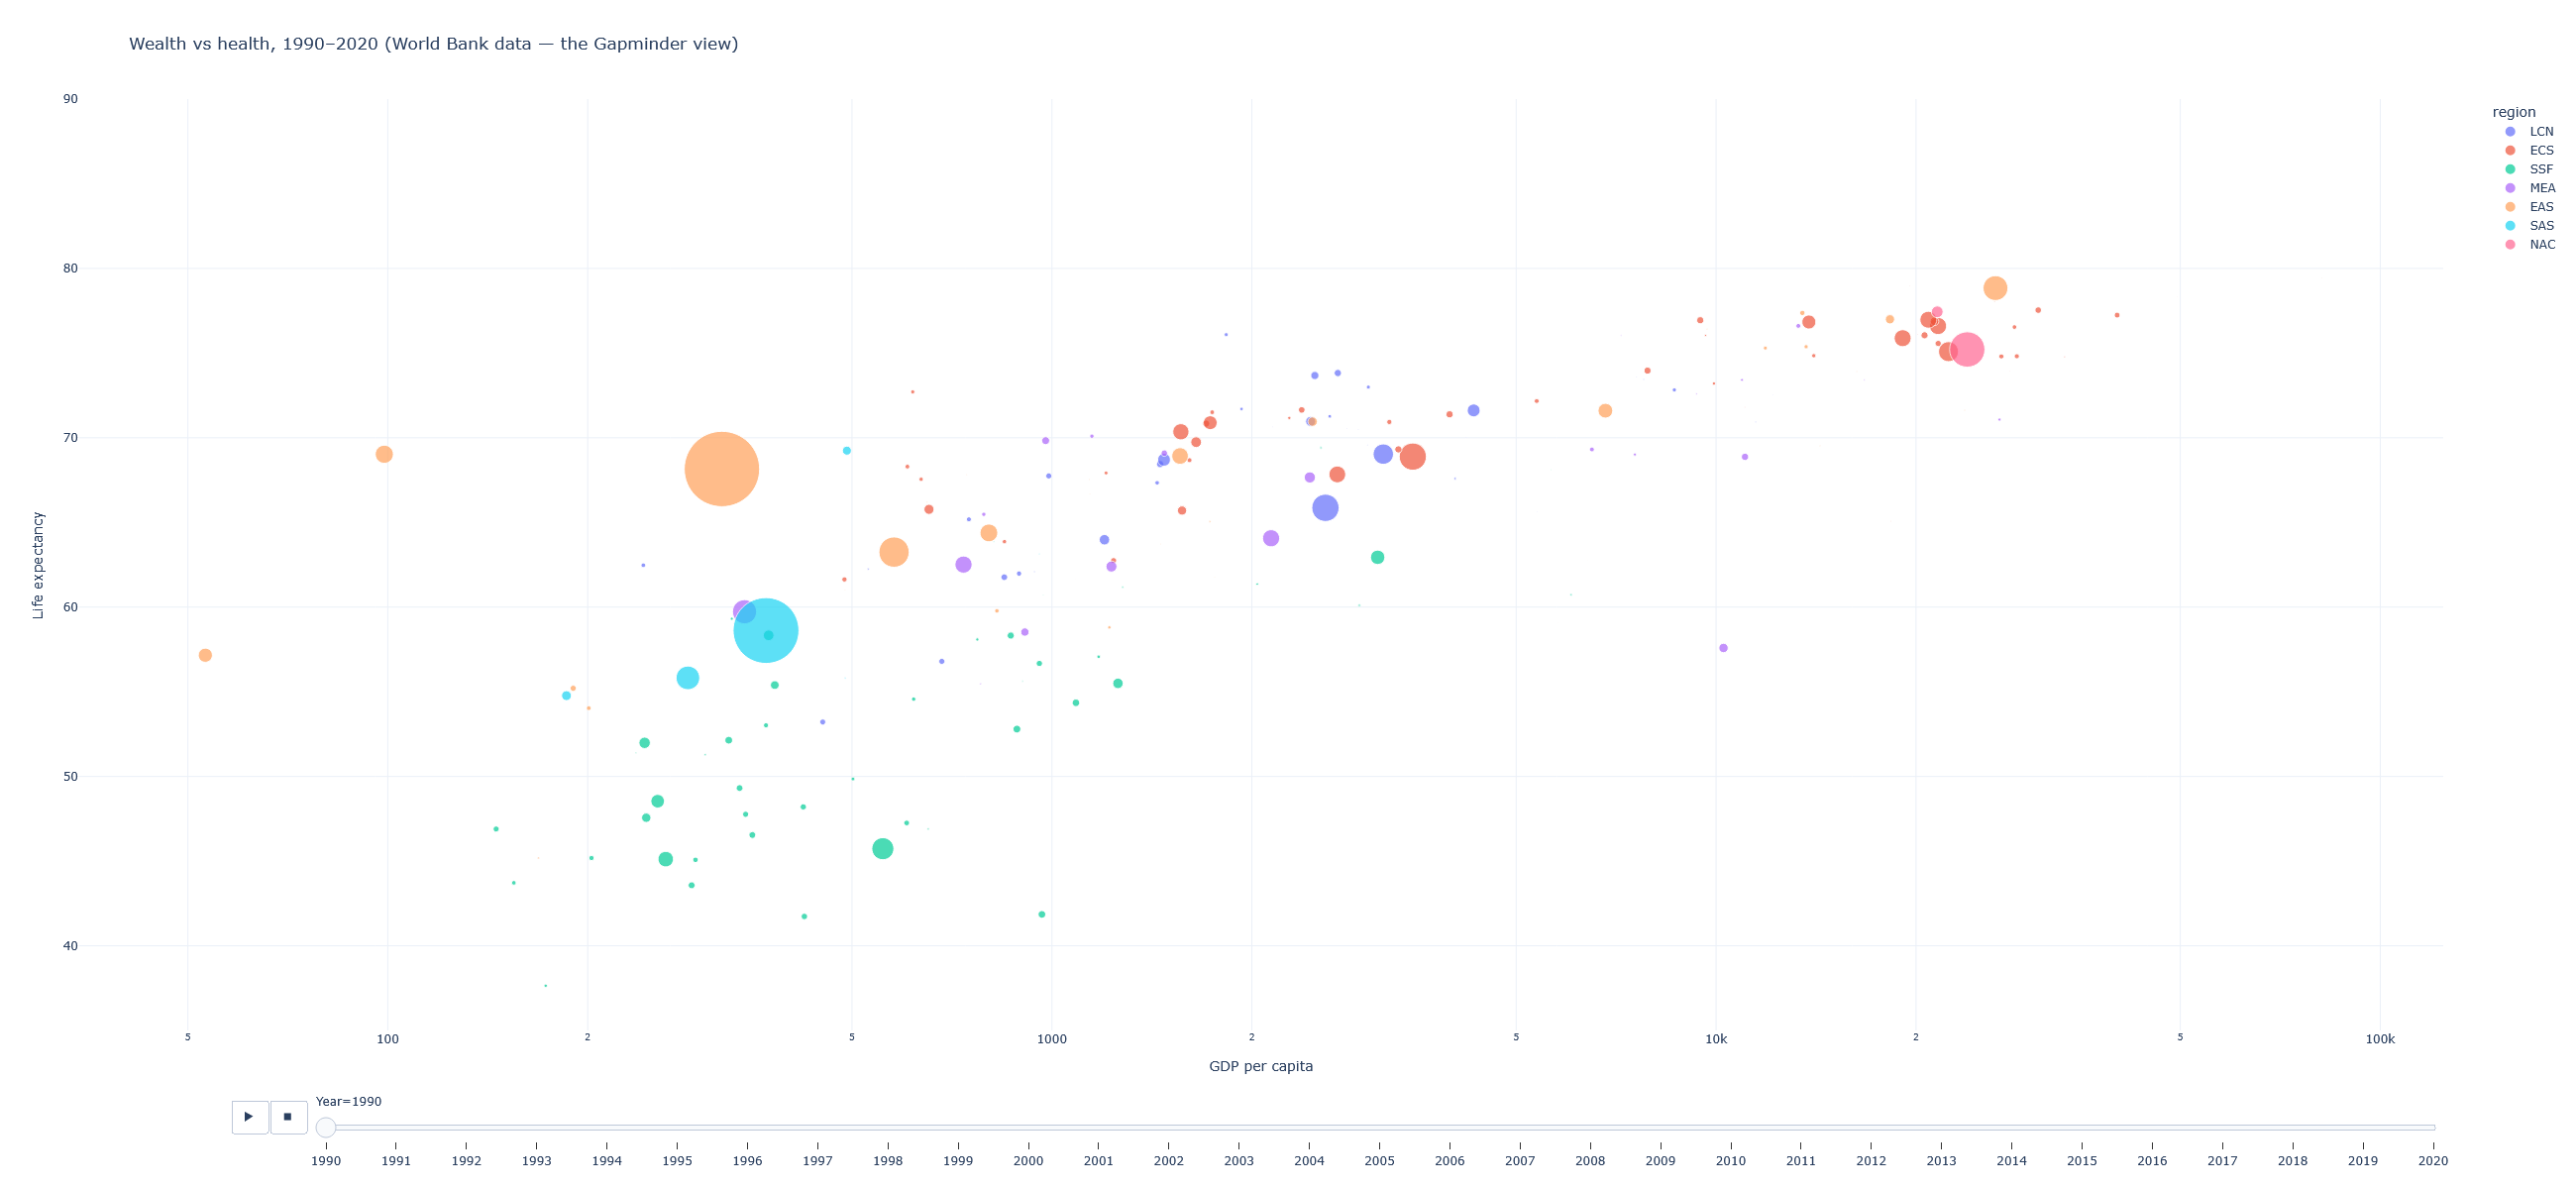

In [117]:
fig = px.scatter(g, x="GDP per capita", y="Life expectancy",
                 size="Population", color="region", hover_name="name",
                 animation_frame="Year", 
                 animation_group="economy",
                 size_max=60, log_x=True, range_y=(35, 90),
                 title="Wealth vs health, 1990\u20132020 (World Bank data \u2014 the Gapminder view)")
fig.update_layout(height=1200)

def set_anim_speed(fig, frame_ms=800, transition_ms=0):
    # Play button
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = frame_ms
    fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = transition_ms
    # Slider steps
    for step in fig.layout.sliders[0].steps:
        step["args"][1]["frame"]["duration"] = frame_ms
        step["args"][1]["transition"]["duration"] = transition_ms

set_anim_speed(fig, frame_ms=300, transition_ms=300)   # 0.8s per year, snap between years

fig.show()

### ESG gaps by income group

The same data can expose structural disparities. Here we compare CO&#8322; per capita across World Bank **income groups** — a stark reminder that emissions and wealth are tightly linked.

In [120]:
print(co2.columns.tolist())
co2

['economy', 'Year', 'Country', 'CO2 per capita']


,economy,Year,Country,CO2 per capita
3073,LVA,1995,Latvia,3.716415
2348,MMR,1995,Myanmar,0.173690
2319,NAM,1995,Namibia,1.117360
2290,NRU,1995,Nauru,0.000000
2261,NPL,1995,Nepal,0.092675
...,...,...,...,...
1798,PRY,2023,Paraguay,1.131244
4089,GEO,2023,Georgia,3.648597
1769,PER,2023,Peru,1.922816
5974,ARG,2023,Argentina,4.169905


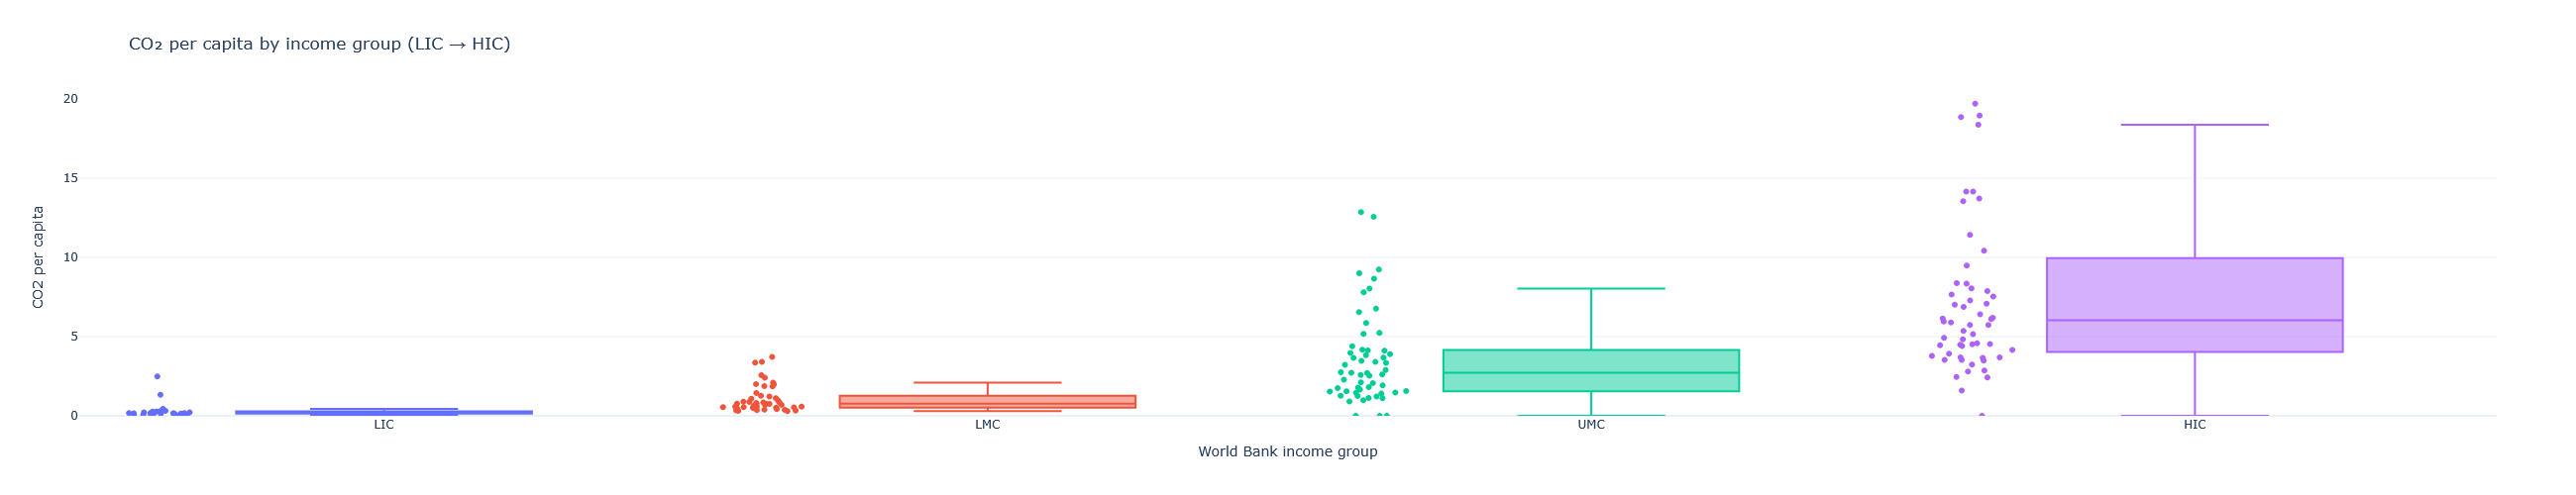

In [121]:
latest = (co2.sort_values("Year").groupby("economy").tail(1)
             .merge(regions, on="economy", how="left")
             .dropna(subset=["incomeLevel"]))

order = ["LIC", "LMC", "UMC", "HIC"]
latest["incomeLevel"] = pd.Categorical(latest["incomeLevel"], categories=order, ordered=True)

fig = px.box(latest.dropna(subset=["incomeLevel"]).sort_values("incomeLevel"),
             x="incomeLevel", y="CO2 per capita", color="incomeLevel",
             range_y=[0, 20],
             points="all", hover_name="name",
             labels={"incomeLevel": "World Bank income group"},
             title="CO\u2082 per capita by income group (LIC \u2192 HIC)")
fig.update_layout(height=500, showlegend=False)
fig.show()

**Act B recap.** With no API key we pulled live country-level ESG indicators, browsed the Bank's dedicated ESG catalogue, and built two world maps plus an animated development chart. The strength here is **global breadth and free access**; the limit is **granularity** — it's countries, not companies. For company-level primary data, we go to the source itself.

---
# <span style="color:#8070FE;">Act C — SEC EDGAR</span>

Every public US company files with the SEC, and **all of it is free** through the EDGAR APIs — no key, no registration. There are no pre-computed ESG scores here; instead we get the raw filings, which teaches something the other two sources hide: **where the numbers actually come from**.

Two rules of good citizenship, both required by the SEC's fair-access policy:
- <span style="color:#AC0000;">Send a **User-Agent** header identifying yourself with a contact email</span> (edit the cell below).
- Stay under **10 requests per second** — we add small pauses automatically.

In [122]:
import requests, time

# ---- EDIT THIS: the SEC asks you to identify yourself with a real contact email ----
SEC_HEADERS = {"User-Agent": "University Finance Class (vitali@uts.edu.au)"}

def sec_get(url, **kwargs):
    """GET an SEC endpoint politely: identify ourselves and pause to respect rate limits."""
    r = requests.get(url, headers=SEC_HEADERS, timeout=30, **kwargs)
    r.raise_for_status()
    time.sleep(0.2)          # keep well under 10 requests/second
    return r

print("SEC helper ready. Remember to put a real email in SEC_HEADERS.")

SEC helper ready. Remember to put a real email in SEC_HEADERS.


### Step 1 — ticker to CIK

EDGAR identifies companies by a **CIK** (Central Index Key), not a ticker. The SEC publishes the full mapping as a single JSON file, which we turn into a lookup. Note the zero-padding to 10 digits — the structured endpoints require it.

In [123]:
def fetch_ticker_map():
    j = sec_get("https://www.sec.gov/files/company_tickers.json").json()
    t = pd.DataFrame.from_dict(j, orient="index")
    t["cik10"] = t["cik_str"].astype(str).str.zfill(10)
    return t

tickers = load_or_fetch_csv("sec_company_tickers.csv", fetch_ticker_map, dtype={"cik10": str})
cik_lookup = dict(zip(tickers["ticker"], tickers["cik10"]))

for tk in ["AAPL", "MSFT", "XOM"]:
    print(f"{tk:5s} \u2192 CIK {cik_lookup[tk]}")

✓ cache hit   → data\sec_company_tickers.csv
AAPL  → CIK 0000320193
MSFT  → CIK 0000789019
XOM   → CIK 0002115436


### Step 2 — a company's recent filings

The submissions endpoint returns a company's filing history. Let's list the most recent annual reports (**10-K**) for a company of your choice.

In [124]:
def company_filings(ticker):
    cik = cik_lookup[ticker]
    j = sec_get(f"https://data.sec.gov/submissions/CIK{cik}.json").json()
    return j["name"], pd.DataFrame(j["filings"]["recent"])

name, recent = company_filings("AAPL")
tenk = recent[recent["form"] == "10-K"][["filingDate", "accessionNumber", "primaryDocument"]].copy()
tenk["filingDate"] = pd.to_datetime(tenk["filingDate"])

print(f"{name} \u2014 recent 10-K filings:")
tenk.head(8)

Apple Inc. — recent 10-K filings:


,filingDate,accessionNumber,primaryDocument
51,2025-10-31,0000320193-25-000079,aapl-20250927.htm
136,2024-11-01,0000320193-24-000123,aapl-20240928.htm
230,2023-11-03,0000320193-23-000106,aapl-20230930.htm
308,2022-10-28,0000320193-22-000108,aapl-20220924.htm
383,2021-10-29,0000320193-21-000105,aapl-20210925.htm
452,2020-10-30,0000320193-20-000096,aapl-20200926.htm
523,2019-10-31,0000320193-19-000119,a10-k20199282019.htm
593,2018-11-05,0000320193-18-000145,a10-k20189292018.htm


### Step 3 — structured financials via XBRL

Beyond the documents, EDGAR exposes **tagged financial facts**. Here we pull one concept — R&amp;D expense — straight from Apple's XBRL data and chart it over time. (Swap the tag for `Revenues`, `NetIncomeLoss`, and so on.)

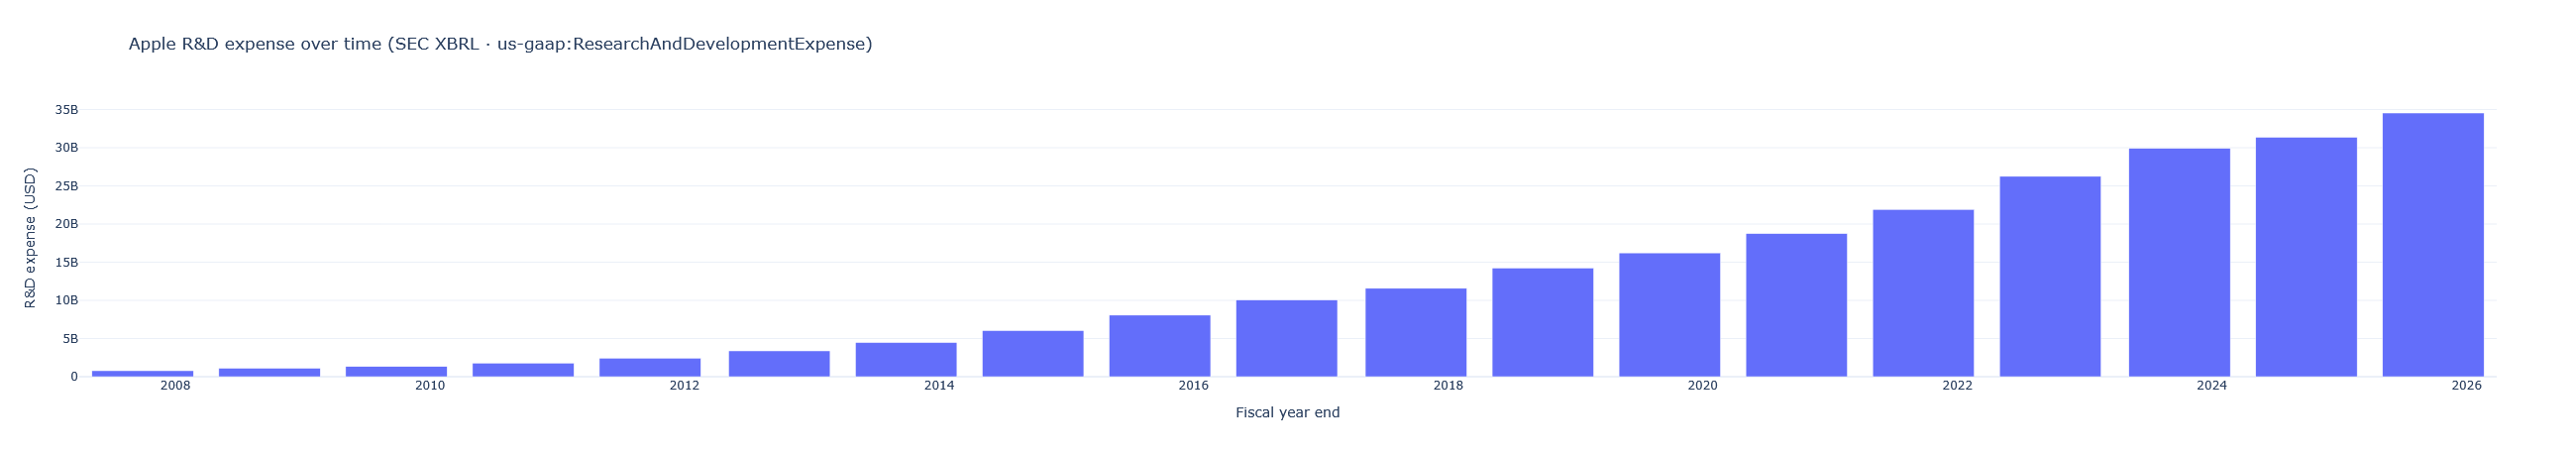

In [125]:
def company_concept(ticker, tag, taxonomy="us-gaap", unit="USD"):
    cik = cik_lookup[ticker]
    j = sec_get(f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/{taxonomy}/{tag}.json").json()
    d = pd.DataFrame(j["units"][unit])
    d["end"] = pd.to_datetime(d["end"])
    return d

rnd = company_concept("AAPL", "ResearchAndDevelopmentExpense")

mask = rnd["form"] == "10-K"
if "fp" in rnd.columns:
    mask &= (rnd["fp"] == "FY")                 # annual figures only
annual = rnd[mask].drop_duplicates("end", keep="last").sort_values("end")

fig = px.bar(annual, x="end", y="val",
             labels={"end": "Fiscal year end", "val": "R&D expense (USD)"},
             title="Apple R&D expense over time (SEC XBRL \u00b7 us-gaap:ResearchAndDevelopmentExpense)")
fig.update_layout(height=460)
fig.show()

### Step 4 — the full-text search trend (the fun one)

EDGAR's **full-text search** indexes the actual words in every filing since 2001. That lets us measure a *theme* rather than a number: how often have annual reports mentioned <span style="color:#2E8B57;"><b>"climate risk"</b></span> over the past decade — and how does that compare with <span style="color:#8070FE;"><b>"artificial intelligence"</b></span>?

We ask the search endpoint for the **count** of matching 10-Ks per year (one quick request each, with a pause between). The result is a neat, teachable trend line built entirely from primary data.

✓ cache hit   → data\sec_theme_trend.csv


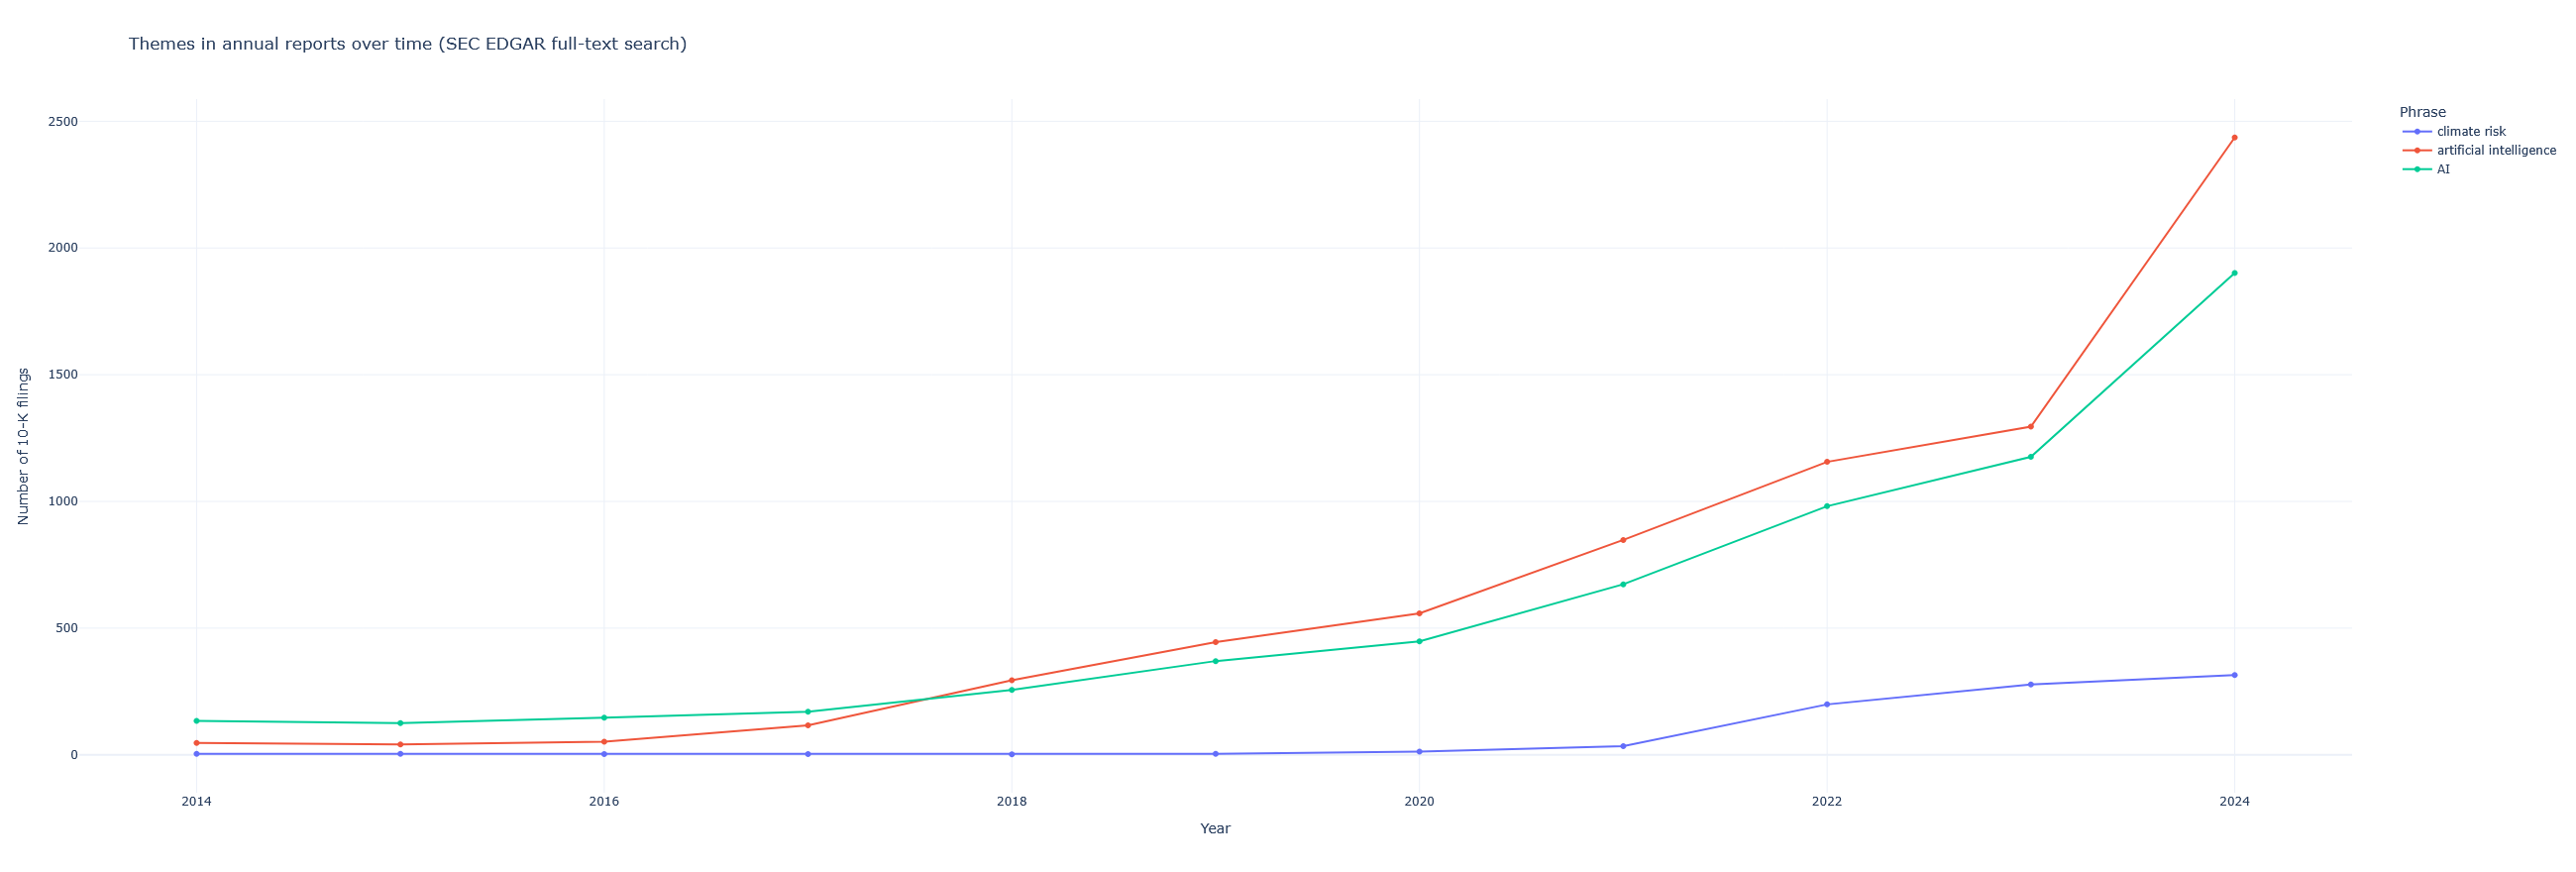

In [126]:
def count_10k_mentions(phrase, year):
    """Number of 10-K filings mentioning an exact phrase in a given year."""
    params = {"q": f'"{phrase}"', "forms": "10-K", "dateRange": "custom",
              "startdt": f"{year}-01-01", "enddt": f"{year}-12-31"}
    j = sec_get("https://efts.sec.gov/LATEST/search-index", params=params).json()
    return j["hits"]["total"]["value"]

def fetch_theme_trend():
    years = list(range(2014, 2025))
    rows = []
    for y in years:
        rows.append({"Year": y,
                     "climate risk": count_10k_mentions("climate risk", y),
                     "artificial intelligence": count_10k_mentions("artificial intelligence", y),
                     "AI": count_10k_mentions("AI", y)})
        time.sleep(0.3)                          # be gentle with the endpoint
    return pd.DataFrame(rows)

trend = load_or_fetch_csv("sec_theme_trend.csv", fetch_theme_trend)

tl = trend.melt("Year", var_name="Phrase", value_name="Number of 10-K filings")
fig = px.line(tl, x="Year", y="Number of 10-K filings", color="Phrase", markers=True,
              title="Themes in annual reports over time (SEC EDGAR full-text search)")
fig.update_layout(height=880)
fig.show()

### Step 5 — can I get the full text? 

Recall, later, we will be looking at some NLP techniques. This example is just a taste.

In [135]:
#!pip install lxml

In [133]:
import re
import pandas as pd
from bs4 import BeautifulSoup

def search_filings(phrase, forms="10-K", year=None, size=10):
    """Return search hits with a fetchable document URL for each filing."""
    params = {"q": f'"{phrase}"', "forms": forms}
    if year:
        params.update(startdt=f"{year}-01-01", enddt=f"{year}-12-31")
    j = sec_get("https://efts.sec.gov/LATEST/search-index", params=params).json()
    #print(j["hits"]["hits"][0]["_source"].keys())
    
    rows = []
    for h in j["hits"]["hits"][:size]:
        src = h["_source"]
        accession, filename = h["_id"].split(":", 1)   # '0000320193-23-000106:aapl-20230930.htm'
        cik = int(src["ciks"][0])                       # stored zero-padded, so cast to int
        url = (f"https://www.sec.gov/Archives/edgar/data/"
               f"{cik}/{accession.replace('-', '')}/{filename}")
        rows.append({"company": src.get("display_names", ["?"])[0],
                     "date": src.get("file_date"),
                     "url": url})
    return pd.DataFrame(rows)

hits = search_filings("climate risk", year=2023)
hits.head()

,company,date,url
0,CARNIVAL CORP (CCL) (CIK 0000815097),2023-01-27,https://www.sec.gov/Archives/edgar/data/815097...
1,Federal Home Loan Bank of Cincinnati (CIK 000...,2023-03-16,https://www.sec.gov/Archives/edgar/data/132677...
2,CARNIVAL CORP (CCL) (CIK 0000815097),2023-01-27,https://www.sec.gov/Archives/edgar/data/815097...
3,"CITIGROUP INC (C, C-PN) (CIK 0000831001)",2023-02-27,https://www.sec.gov/Archives/edgar/data/831001...
4,"MORGAN STANLEY (MS, MS-PA, MS-PE, MS-PF, MS-P...",2023-02-24,https://www.sec.gov/Archives/edgar/data/895421...


In [139]:
# def fetch_filing_text(url):
#     """Download a filing and return plain text (scripts, styles and markup removed)."""
#     html = sec_get(url).text
#     #soup = BeautifulSoup(html, "lxml")
#     soup = BeautifulSoup(html, "html.parser")
#     for tag in soup(["script", "style"]):
#         tag.decompose()
#     text = soup.get_text(separator=" ")
#     return re.sub(r"\s+", " ", text).strip()

def fetch_filing_text(url):
    """Download a filing and return readable narrative text, minus inline-XBRL tagging."""
    html = sec_get(url).text
    soup = BeautifulSoup(html, "html.parser")

    # Drop scripts, styles, and the inline-XBRL layer.
    for tag in soup(["script", "style"]):
        tag.decompose()
    for tag in soup.find_all(re.compile(r"^ix:", re.I)):      # inline-XBRL elements
        tag.decompose()
    hidden = soup.find(attrs={"style": re.compile(r"display:\s*none", re.I)})
    if hidden:
        hidden.decompose()

    text = soup.get_text(separator=" ")
    return re.sub(r"\s+", " ", text).strip()
    
text = fetch_filing_text(hits.iloc[0]["url"])
print(len(text), "characters")
print(text[:10500])          # display a snippet so students see what they're working with

214846 characters
ccl-20221130 UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549 FORM (Mark One) ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended or TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the transition period from ______________ to ________________ Commission file number: (Exact name of registrant as specified in its charter) (Exact name of registrant as specified in its charter) Republic of (State or other jurisdiction of incorporation or organization) (State or other jurisdiction of incorporation or organization) (I.R.S. Employer Identification No.) (I.R.S. Employer Identification No.) (Address of principal executive offices and zip code) (Address of principal executive offices and zip code) Commission file number: (Registrant’s telephone number, including area code) (Registrant’s telephone number, including area code) Securities registered pursua

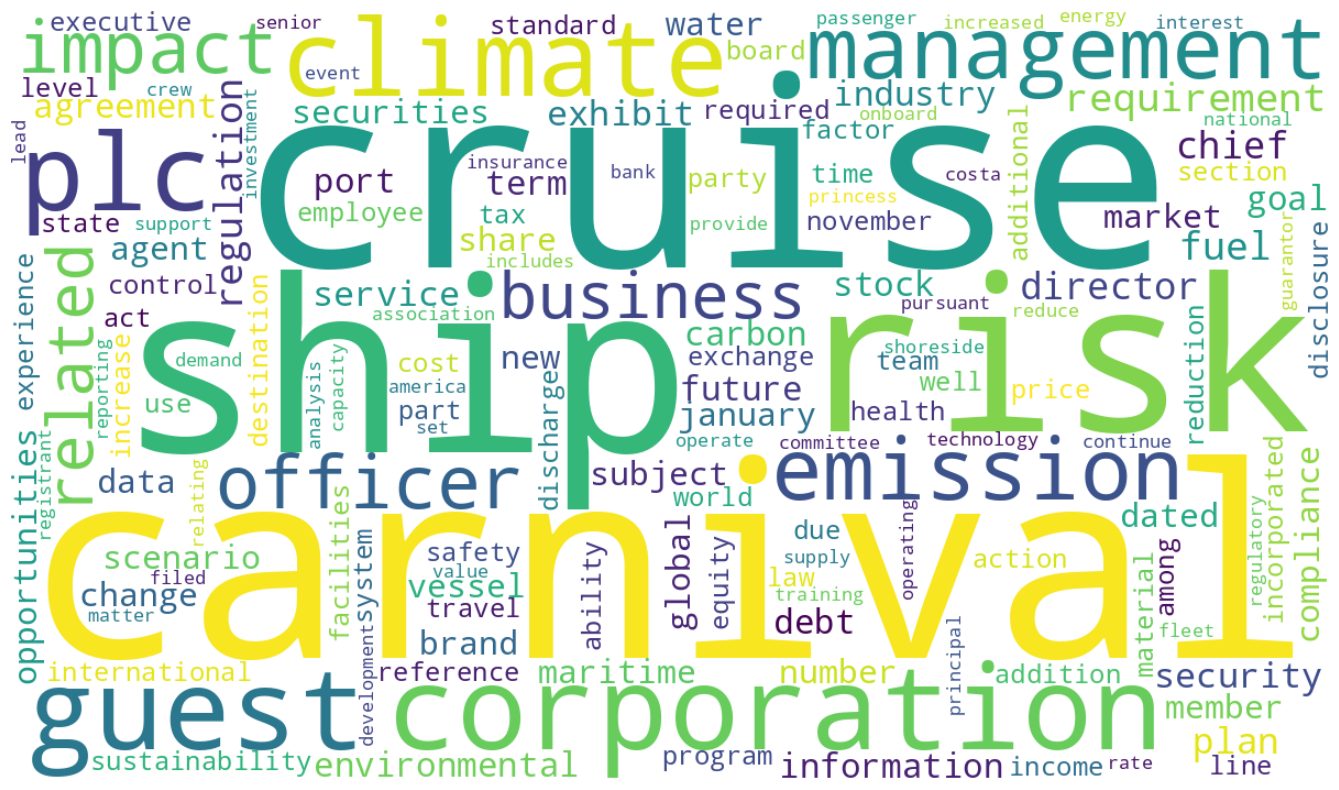

In [140]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

FINANCE_STOPWORDS = {
    "company", "companies", "fiscal", "year", "years", "may", "also", "including",
    "include", "included", "operations", "results", "financial", "statements",
    "report", "annual", "form", "item", "note", "notes", "shall", "will", "based",
    "certain", "million", "billion", "period", "date", "table", "contents",
    "respectively", "primarily", "approximately", "december", "subsidiary",
}

def make_wordcloud(text, extra_stopwords=None, max_words=150):
    words = re.findall(r"[a-z][a-z\-]{2,}", text.lower())     # letters only, drops numbers
    cleaned = " ".join(words)
    stops = set(STOPWORDS) | FINANCE_STOPWORDS | (extra_stopwords or set())

    wc = WordCloud(width=1200, height=700, background_color="white",
                   stopwords=stops, max_words=max_words,
                   collocations=False).generate(cleaned)   # False → no duplicate bigrams

    plt.figure(figsize=(14, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off"); plt.tight_layout(); plt.show()
    return wc

make_wordcloud(text)

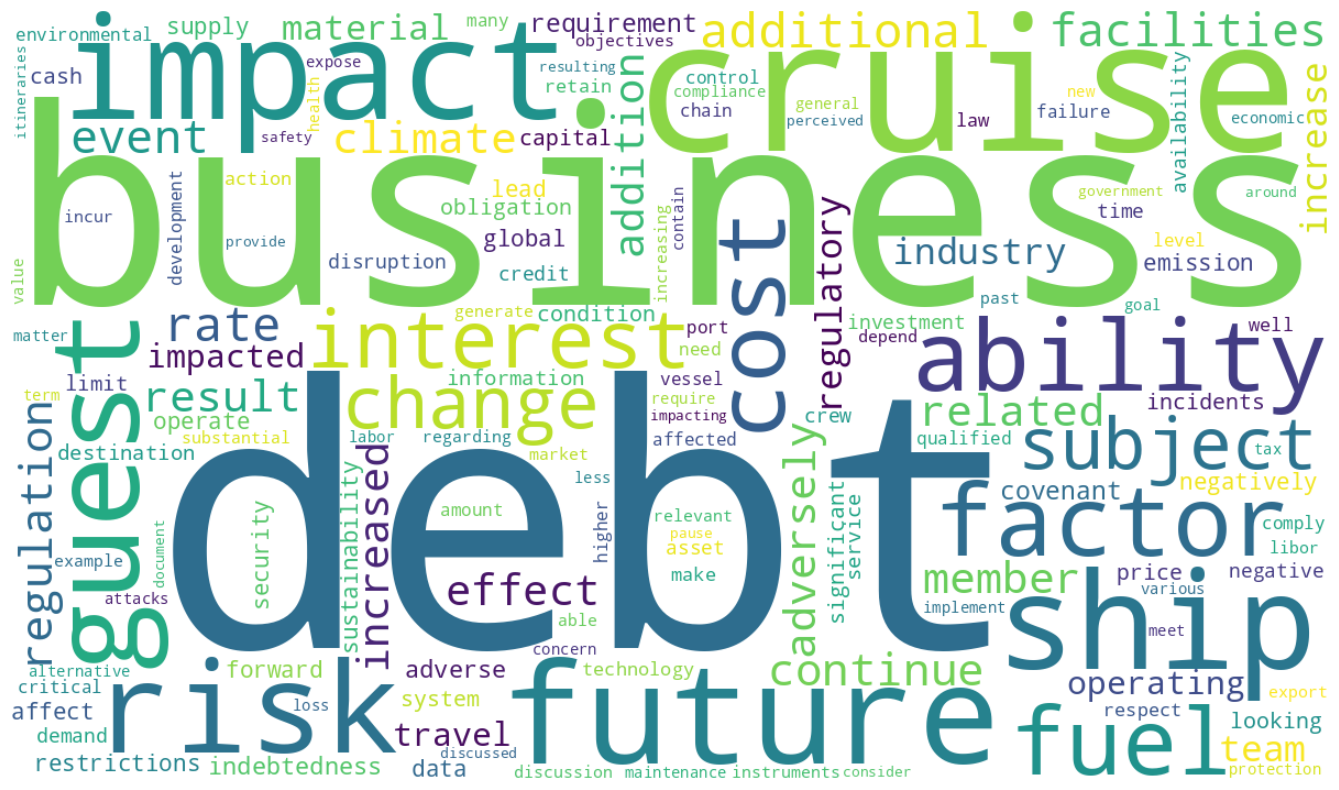

In [141]:
def extract_section(text, start="Item 1A", end="Item 1B"):
    """Approximate slice of a 10-K section. Filings vary — this is a teaching heuristic."""
    lo = text.lower()
    i = lo.find(start.lower(), lo.find(start.lower()) + 1)   # 2nd hit skips the contents page
    j = lo.find(end.lower(), i + 1)
    return text[i:j] if i != -1 and j != -1 else text

make_wordcloud(extract_section(text))

**Act C recap.** Directly from the SEC, and for free, we mapped tickers to CIKs, listed a company's filings, pulled tagged financials, and measured how a sustainability theme has spread through a decade of annual reports. This is the most **raw and flexible** source — and the most work, since you build the analysis yourself.

---
# <span style="color:#8070FE;">Wrapping up — which source, when?</span>

| | <span style="color:#2E8B57;">Static dataset</span> | <span style="color:#1F6FEB;">World Bank</span> | <span style="color:#B8860B;">SEC EDGAR</span> |
|---|---|---|---|
| **Granularity** | Company (S&P 500) | Country | Company (US filers) |
| **Cost / key** | Free, no key | Free, no key | Free, no key |
| **Freshness** | Fixed snapshot | Annual, updated | Real-time filings |
| **Best for** | Reproducible teaching, drop-in for Yahoo | Global maps & trends | Primary data, text analysis |
| **Main limitation** | Static & dated | Not company-level | No ready-made scores |

### Reproducibility for class
Everything Acts B and C downloaded now sits in the `data/` folder. **Commit that folder** alongside the notebook and the whole thing runs offline and identically for every student — no live-API surprises mid-lecture.

### Refreshing or swapping the Act A data
The bundled `data/sp500_esg.csv` is a teaching snapshot. To use fresher or broader ESG figures, drop in any CSV with the same column names (e.g. Kaggle's "S&P 500 ESG Risk Ratings"), or extend the universe beyond the S&P 500. Market caps can be topped up from a live source if you need current values.

### Go further
- Merge Act A's ESG risk with the Act C financials and test whether lower ESG risk lines up with valuation or returns.
- In Act B, colour the Gapminder bubbles by a **governance** indicator from database `75` instead of by region.
- In Act C, swap `"climate risk"` for your own theme, or search proxy statements (`DEF 14A`) instead of 10-Ks.